# Bayesian testing

In [3]:
import math

import numpy as np
from tqdm.notebook import tqdm

import seaborn as sns
import matplotlib.pyplot as plt


from  scipy import stats
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde
from scipy.stats import multivariate_normal


np.random.seed(0)

Data generating process / Data

$$x_i \sim N(1, 3)$$

In [4]:
x_mu = 1
x_sig2 = math.sqrt(3)
data = np.random.randn(100)*x_sig2 + x_mu

#True grid for
grid = np.linspace(-10, 10, 500)
true_pdf = lambda x: stats.norm.pdf(x, x_mu, x_sig2)
true_pdf_points = true_pdf(grid)

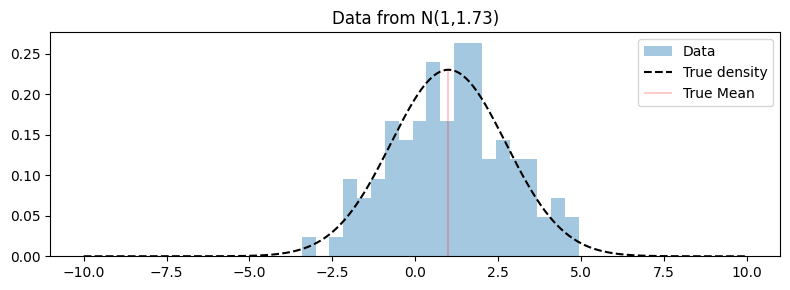

In [5]:
plt.figure(figsize=(8, 3))
plt.hist(data, bins=20, density=True, alpha=0.4, label='Data')
plt.plot(grid, true_pdf_points, 'k--', label='True density')
plt.vlines(x_mu, 0, max(true_pdf_points), colors="red", alpha=0.2, label="True Mean")
plt.legend()
plt.title(fr'Data from N({x_mu},{x_sig2:.2f})')
plt.tight_layout()
plt.show()

# 1: standard bayes - Closed form just mean
Using: Gaussian likelihood: $x_i \sim N(\theta, 1)$ \
Prior of: N(0, 100)

Posterior (proportional to likelihood $\times$ prior):
$$
\pi(\theta \mid \mathbf{x}) \propto \exp\!\left(-\frac{1}{2}\left[\left(n + \frac{1}{100}\right)\theta^2 - 2n\bar{x}\,\theta\right]\right)
$$


Result:
$$
\theta \mid \mathbf{x} \sim N\!\left(\frac{n\bar{x}}{n + 1/100},\; \frac{1}{n + 1/100}\right)
$$

C:\Users\samue\AppData\Local\Temp\ipykernel_44740\422895490.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(theta_grid, posterior , 'r-', label='Posterior', color="tab:blue")


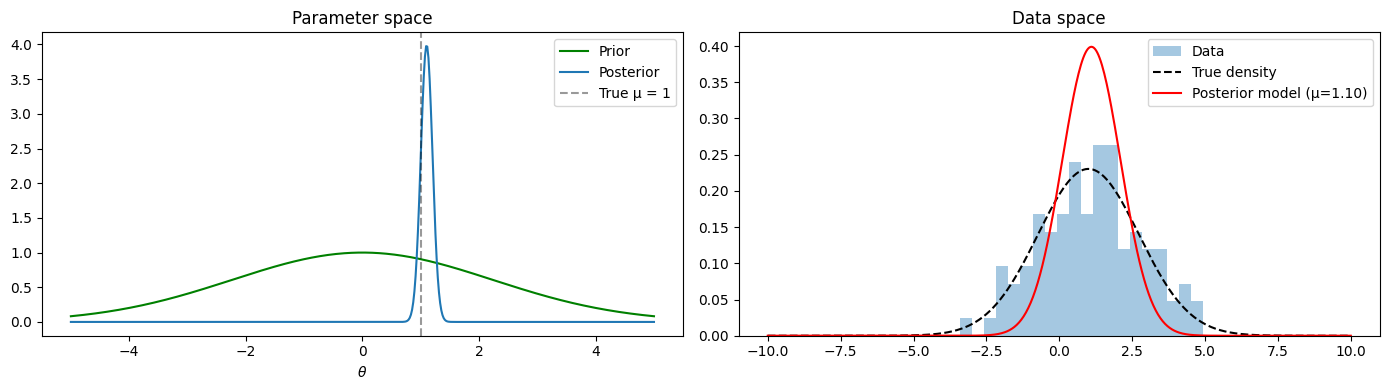

Posterior: N(1.1014, 0.0100)


In [6]:
n = len(data)
x_bar = np.mean(data)

# Prior: N(0, 100)
prior_mu = 0
prior_sig2 = 5

# Posterior (closed form)
post_sig2 = 1 / (n + 1 / prior_sig2)
post_mu = post_sig2 * n * x_bar

# Parameter space grid
theta_grid = np.linspace(-5, 5, 500)

# Likelihood over theta: product of N(x_i | theta, 1) => proportional to N(x_bar, 1/n)
likelihood = stats.norm.pdf(theta_grid, x_bar, np.sqrt(1 / n))
prior = stats.norm.pdf(theta_grid, prior_mu, np.sqrt(prior_sig2))
posterior = stats.norm.pdf(theta_grid, post_mu, np.sqrt(post_sig2))

# --- Plot 1: Parameter space ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(theta_grid, prior / prior.max(), 'g-', label='Prior')
# ax.plot(theta_grid, likelihood / likelihood.max(), 'b-', label='Likelihood')
ax.plot(theta_grid, posterior , 'r-', label='Posterior', color="tab:blue")
ax.axvline(x_mu, color='k', ls='--', alpha=0.4, label=f'True μ = {x_mu}')
ax.set_xlabel(r'$\theta$')
ax.set_title('Parameter space')
ax.legend()

# --- Plot 2: Data space — fitted model vs true density ---
ax = axes[1]
ax.hist(data, bins=20, density=True, alpha=0.4, label='Data')
ax.plot(grid, true_pdf_points, 'k--', label='True density')
ax.plot(grid, stats.norm.pdf(grid, post_mu, 1), 'r-', label=f'Posterior model (μ={post_mu:.2f})')
ax.set_title('Data space')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Posterior: N({post_mu:.4f}, {post_sig2:.4f})")

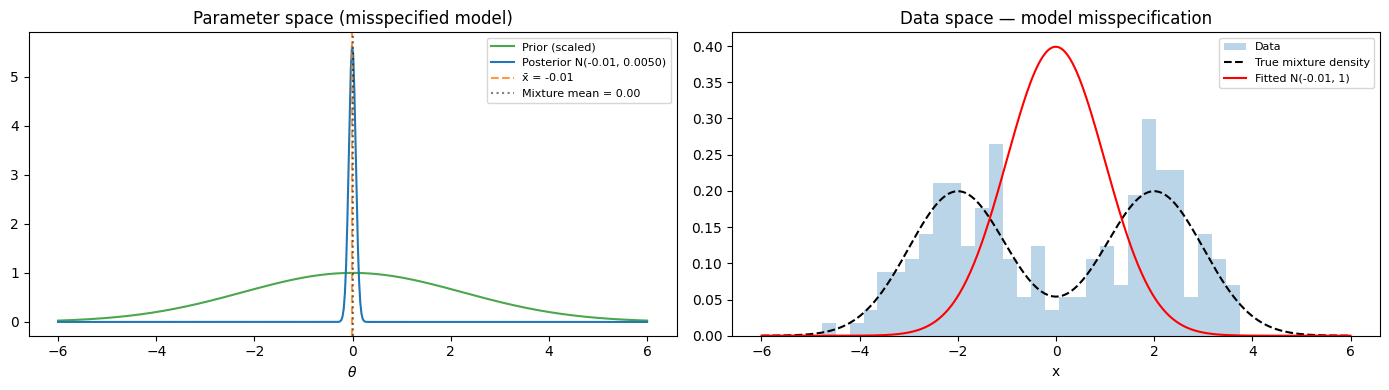

Posterior: N(-0.0060, 0.0050)
x̄ = -0.0060,  mixture mean = 0.0000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- DGP parameters ---
n = 200
mu1, mu2 = -2.0, 2.0
pi = 0.5  # mixing weight

# --- Sample from mixture ---
z = np.random.binomial(1, pi, size=n)
data = z * np.random.normal(mu1, 1, n) + (1 - z) * np.random.normal(mu2, 1, n)

# --- Misspecified model: x_i | theta ~ N(theta, 1), prior theta ~ N(0, 5) ---
x_bar = np.mean(data)
prior_mu = 0
prior_sig2 = 5

post_sig2 = 1 / (n + 1 / prior_sig2)
post_mu = post_sig2 * n * x_bar

# --- Grids ---
theta_grid = np.linspace(-6, 6, 500)
data_grid = np.linspace(-6, 6, 500)

# --- Parameter space curves ---
prior = stats.norm.pdf(theta_grid, prior_mu, np.sqrt(prior_sig2))
posterior = stats.norm.pdf(theta_grid, post_mu, np.sqrt(post_sig2))

# --- Data space curves ---
true_pdf = pi * stats.norm.pdf(data_grid, mu1, 1) + (1 - pi) * stats.norm.pdf(data_grid, mu2, 1)
fitted_pdf = stats.norm.pdf(data_grid, post_mu, 1)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(theta_grid, prior / prior.max(), 'g-', label='Prior (scaled)', alpha=0.7)
ax.plot(theta_grid, posterior, label=f'Posterior N({post_mu:.2f}, {post_sig2:.4f})', color='tab:blue')
ax.axvline(x_bar, color='tab:orange', ls='--', alpha=0.8, label=f'x̄ = {x_bar:.2f}')
ax.axvline(pi * mu1 + (1 - pi) * mu2, color='k', ls=':', alpha=0.5, label=f'Mixture mean = {pi*mu1+(1-pi)*mu2:.2f}')
ax.set_xlabel(r'$\theta$')
ax.set_title('Parameter space (misspecified model)')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(data, bins=30, density=True, alpha=0.3, label='Data', color='tab:blue')
ax.plot(data_grid, true_pdf, 'k--', label=f'True mixture density')
ax.plot(data_grid, fitted_pdf, 'r-', label=f'Fitted N({post_mu:.2f}, 1)')
ax.set_xlabel('x')
ax.set_title('Data space — model misspecification')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Posterior: N({post_mu:.4f}, {post_sig2:.4f})")
print(f"x̄ = {x_bar:.4f},  mixture mean = {pi*mu1 + (1-pi)*mu2:.4f}")

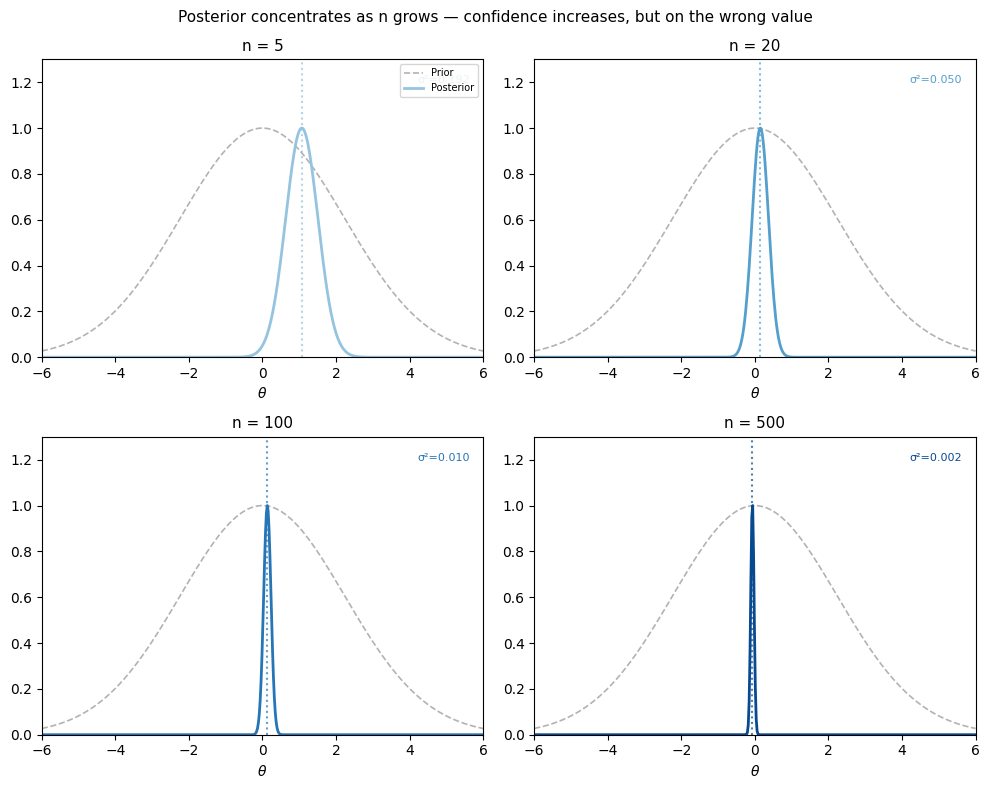

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- DGP parameters ---
mu1, mu2 = -2.0, 2.0
pi = 0.5
prior_mu = 0
prior_sig2 = 5

ns = [5, 20, 100, 500]
theta_grid = np.linspace(-6, 6, 500)

np.random.seed(42)
all_data = np.array([
    (np.random.binomial(1, pi) * np.random.normal(mu1, 1) +
     (1 - np.random.binomial(1, pi)) * np.random.normal(mu2, 1))
    for _ in range(max(ns))
])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ns)))

prior = stats.norm.pdf(theta_grid, prior_mu, np.sqrt(prior_sig2))

for idx, (n, color) in enumerate(zip(ns, colors)):
    ax = axes[idx // 2, idx % 2]
    data = all_data[:n]
    x_bar = np.mean(data)
    post_sig2 = 1 / (n + 1 / prior_sig2)
    post_mu = post_sig2 * n * x_bar

    posterior = stats.norm.pdf(theta_grid, post_mu, np.sqrt(post_sig2))

    ax.plot(theta_grid, prior / prior.max(), color='gray', lw=1.2, ls='--', alpha=0.6, label='Prior')
    ax.plot(theta_grid, posterior / posterior.max(), color=color, lw=2, label='Posterior')
    ax.axvline(post_mu, color=color, ls=':', alpha=0.7)
    ax.set_title(f'n = {n}', fontsize=11)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylim(0, 1.3)
    ax.set_xlim(-6, 6)
    ax.annotate(f'σ²={post_sig2:.3f}', xy=(0.97, 0.92), xycoords='axes fraction',
                ha='right', fontsize=8, color=color)
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle('Posterior concentrates as n grows — confidence increases, but on the wrong value', fontsize=11)
plt.tight_layout()
plt.show()

# 2: Two-parameter model — $N(\theta, \sigma^2)$ via MCMC

Both mean and variance are unknown.

**Likelihood:** $x_i \sim N(\theta, \sigma^2)$

**Priors:**
- $\theta \sim N(0, 100)$
- $\sigma^2 \sim \text{InvGamma}(1, 1)$

**Method:** Metropolis-Hastings random walk. Propose:
$$
\theta' \sim N(\theta, \delta_\theta^2), \quad \sigma^{2\prime} \sim N(\sigma^2, \delta_\sigma^2)
$$

Accept with probability $\min\!\left(1,\; \frac{\pi(\theta', \sigma^{2\prime} \mid x)}{\pi(\theta, \sigma^2 \mid x)}\right)$

Acceptance rate: 28.91%


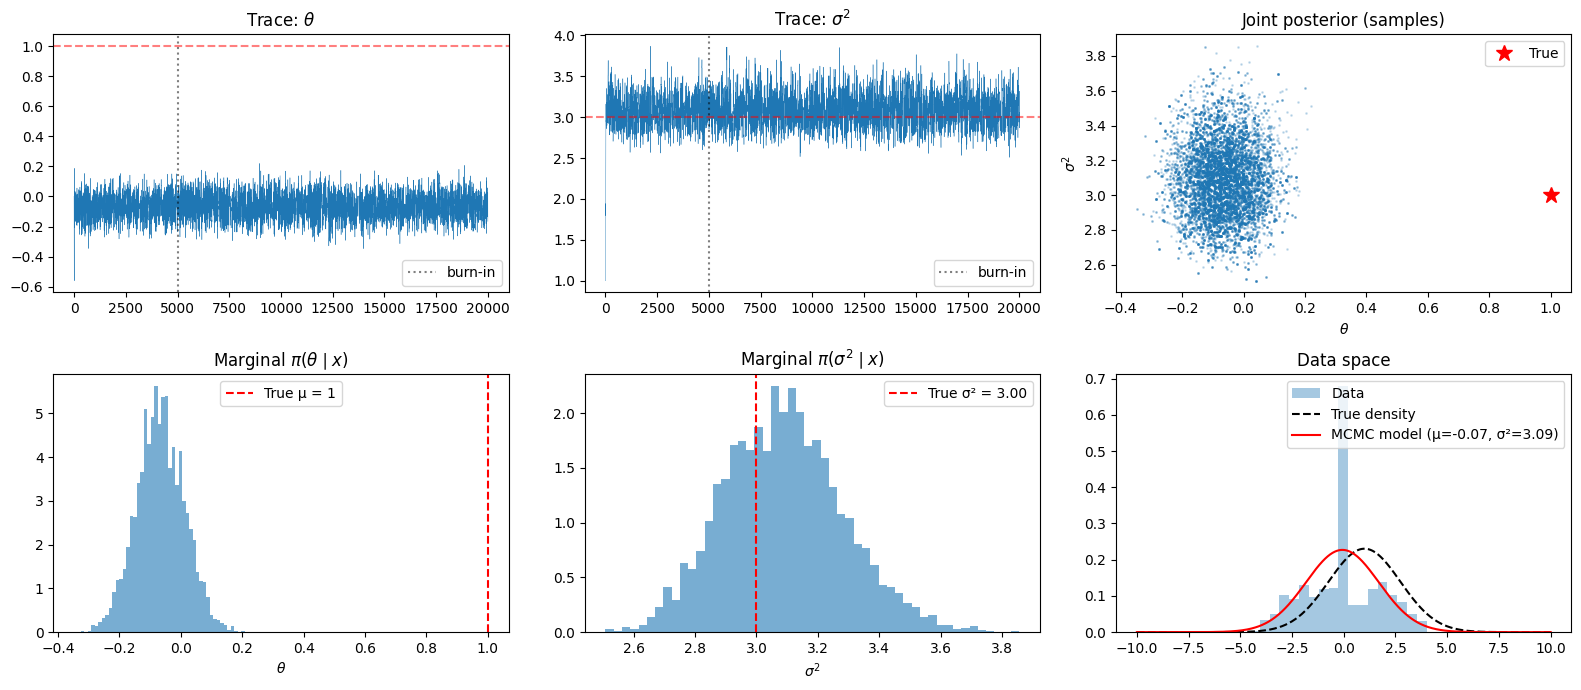

Posterior mean: θ = -0.066, σ² = 3.088
True values:   θ = 1, σ² = 3.000


In [9]:
# --- Metropolis-Hastings MCMC ---
def log_posterior(theta, sig2, data):
    """Unnormalised log-posterior: log-likelihood + log-priors"""
    if sig2 <= 0:
        return -np.inf
    log_lik = np.sum(stats.norm.logpdf(data, loc=theta, scale=np.sqrt(sig2)))
    log_prior_theta = stats.norm.logpdf(theta, 0, np.sqrt(100))
    log_prior_sig2 = stats.invgamma.logpdf(sig2, a=1, scale=1)
    return log_lik + log_prior_theta + log_prior_sig2

n_samples = 20000
burn_in = 5000

# Proposal step sizes
step_theta = 0.2
step_sig2 = 0.3

# Storage
samples = np.zeros((n_samples, 2))  # columns: theta, sig2
samples[0] = [0.0, 1.0]  # initial values

accepted = 0

for i in range(1, n_samples):
    theta_curr, sig2_curr = samples[i - 1]

    # Propose
    theta_prop = np.random.normal(theta_curr, step_theta)
    sig2_prop = np.random.normal(sig2_curr, step_sig2)

    # Accept/reject
    log_alpha = log_posterior(theta_prop, sig2_prop, data) - log_posterior(theta_curr, sig2_curr, data)

    if np.log(np.random.rand()) < log_alpha:
        samples[i] = [theta_prop, sig2_prop]
        accepted += 1
    else:
        samples[i] = [theta_curr, sig2_curr]

chain = samples[burn_in:]
print(f"Acceptance rate: {accepted / n_samples:.2%}")

# --- Plots ---
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

# Trace plots
axes[0, 0].plot(samples[:, 0], lw=0.3)
axes[0, 0].axhline(x_mu, color='r', ls='--', alpha=0.5)
axes[0, 0].axvline(burn_in, color='k', ls=':', alpha=0.5, label='burn-in')
axes[0, 0].set_title(r'Trace: $\theta$')
axes[0, 0].legend()

axes[0, 1].plot(samples[:, 1], lw=0.3)
axes[0, 1].axhline(x_sig2**2, color='r', ls='--', alpha=0.5)
axes[0, 1].axvline(burn_in, color='k', ls=':', alpha=0.5, label='burn-in')
axes[0, 1].set_title(r'Trace: $\sigma^2$')
axes[0, 1].legend()

# Joint posterior (scatter)
axes[0, 2].scatter(chain[:, 0], chain[:, 1], s=1, alpha=0.2)
axes[0, 2].plot(x_mu, x_sig2**2, 'r*', ms=12, label='True')
axes[0, 2].set_xlabel(r'$\theta$'); axes[0, 2].set_ylabel(r'$\sigma^2$')
axes[0, 2].set_title('Joint posterior (samples)')
axes[0, 2].legend()

# Marginal for theta
axes[1, 0].hist(chain[:, 0], bins=50, density=True, alpha=0.6)
axes[1, 0].axvline(x_mu, color='r', ls='--', label=f'True μ = {x_mu}')
axes[1, 0].set_xlabel(r'$\theta$')
axes[1, 0].set_title(r'Marginal $\pi(\theta \mid x)$')
axes[1, 0].legend()

# Marginal for sigma^2
axes[1, 1].hist(chain[:, 1], bins=50, density=True, alpha=0.6)
axes[1, 1].axvline(x_sig2**2, color='r', ls='--', label=f'True σ² = {x_sig2**2:.2f}')
axes[1, 1].set_xlabel(r'$\sigma^2$')
axes[1, 1].set_title(r'Marginal $\pi(\sigma^2 \mid x)$')
axes[1, 1].legend()

# Data space: model from posterior mean vs true
post_mean_theta = chain[:, 0].mean()
post_mean_sig2 = chain[:, 1].mean()
axes[1, 2].hist(data, bins=20, density=True, alpha=0.4, label='Data')
axes[1, 2].plot(grid, true_pdf_points, 'k--', label='True density')
axes[1, 2].plot(grid, stats.norm.pdf(grid, post_mean_theta, np.sqrt(post_mean_sig2)), 'r-',
                label=f'MCMC model (μ={post_mean_theta:.2f}, σ²={post_mean_sig2:.2f})')
axes[1, 2].set_title('Data space')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Posterior mean: θ = {post_mean_theta:.3f}, σ² = {post_mean_sig2:.3f}")
print(f"True values:   θ = {x_mu}, σ² = {x_sig2**2:.3f}")

## Testing: A rigorous link between deep ensembles and variational bayesian methods

The general framework in equation (4) of the paper is:

$$L(Q) := \int V(\theta) dQ(\theta) + \frac{\lambda_1}{2} \iint \kappa(\theta, \theta') dQ(\theta) dQ(\theta') + \lambda_2 \int \log q(\theta) q(\theta) d\theta$$
where 

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_1 \int (\nabla_1 \kappa)(\theta, \theta'), dQ(\theta') + \lambda_2 \nabla \log q(\theta)$$
And we will be working through From https://arxiv.org/pdf/2305.15027, section G1: toy exmaple: global minimiser

#### 1. Unregularised probabilistic lifting: deep ensembles
This is just the first term of the eqn



In [10]:
lambda_2 = 1
lambda_1 = 1 

loss = lambda theta: (3/2) * (1/4 * theta**4 + 1/3 * theta**3 - theta**2) - 3/8
grad_loss = lambda theta: (3/2) * (theta**3 + theta**2 - 2*theta)
# Where V includes the prior
grad_V = lambda theta: grad_loss(theta) + lambda_2 *theta

prior_dist = stats.norm(0, 1)  # N(0, 1)
prior = prior_dist.pdf
log_prior = prior_dist.logpdf


NE = 300 # 300 particles 
eta = 1e-4
K = 100000

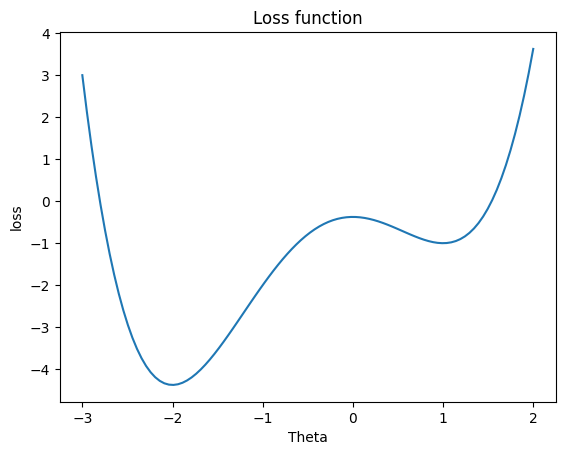

In [11]:
grid = np.linspace(-3,2, 100)
loss_points = loss(grid)

plt.title("Loss function")
plt.xlabel("Theta")
plt.ylabel('loss')
plt.plot(grid, loss_points)
plt.show()

Init the particles from the prior:
$$\theta_1 (0), \dots, \theta_n (0) \sim  Q_0\text{ , in this case the prior is $N(0,1)$ }$$

In [12]:
sample_prior = prior_dist.rvs
particles = sample_prior(size=NE)


$$L(Q) := \int V(\theta) dQ(\theta)$$
$$\nabla_W L[Q](\theta) = \nabla V(\theta) $$
with the particle updates following (for our case of $\lambda_1 = \lambda_2 = 0$):
$$d\theta_n(t) = - \nabla V (\theta_n(t)) dt$$
discretisiing
$$\theta_n^{(k+1)} = \theta_n^{(k)} - \eta \nabla V(\theta_n^{(k)})$$

In [13]:
for t in range(K):
    particles = particles - eta * grad_loss(particles) 

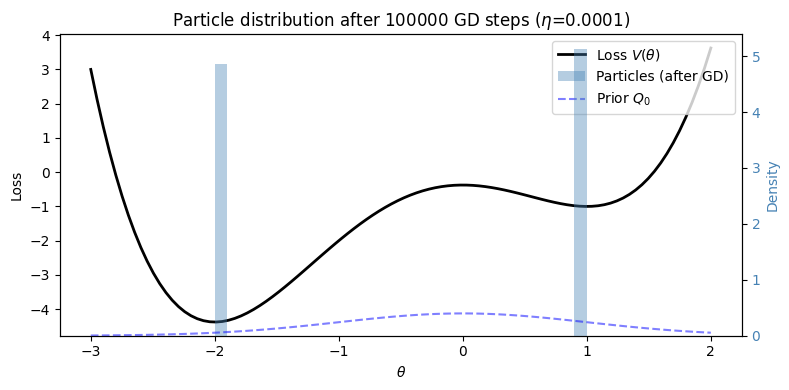

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(grid, loss_points, 'k-', lw=2, label='Loss $V(\\theta)$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Particle distribution on right axis
ax2 = ax1.twinx()
ax2.hist(particles, bins=30, density=True, alpha=0.4, color='steelblue', label='Particles (after GD)')
ax2.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label='Prior $Q_0$')
ax2.set_ylabel('Density', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'Particle distribution after {K} GD steps ($\\eta$={eta})')
plt.tight_layout()
plt.show()

#### Regularisation with the Kullback-Leibler divergence: Deep Langevin ensembles
$$+ \lambda_2 \int \log q(\theta) q(\theta) d\theta$$
is the negative entropy of $Q$. Make entropy large -> spread particles out. \
In the partical update step

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_2 \nabla \log q(\theta)$$

such that
$$\theta_1(0), \dots, \theta_{N_E}(0) \sim Q_0 \quad d\theta_n(t) = -\nabla V(\theta_n(t))dt + \sqrt{2\lambda}dB_n(t), \quad n=1, \dots, N_E.$$

Note that: For some reason the entropy goes to brownian motion. note this is what lagevin mechainics is apparently

optimal based on posterior
$$q^*(\theta) \propto e^{-\frac{V(\theta)}{\lambda_2}} p (\theta)$$

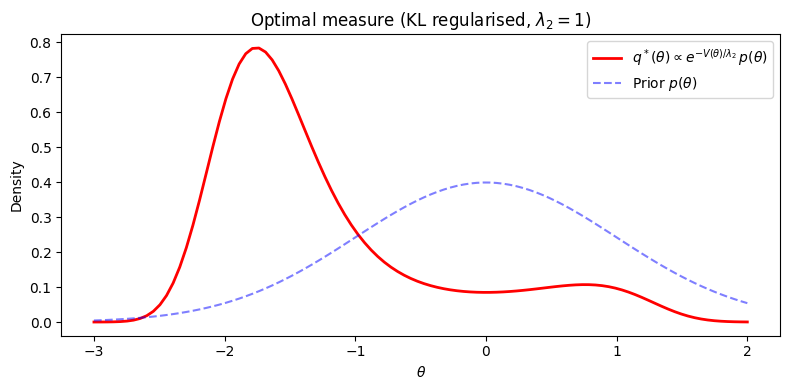

In [15]:
# Optimal measure: q*(theta) ∝ exp(-V(theta)/lambda_2) * prior(theta)
lambda_2 = 1
optimal_vals = np.exp(-loss(grid) / lambda_2) * prior(grid)
optimal_vals /= np.trapz(optimal_vals, grid)  # normalise

plt.figure(figsize=(8, 4))
plt.plot(grid, optimal_vals, 'r-', lw=2, label=r'$q^*(\theta) \propto e^{-V(\theta)/\lambda_2}\, p(\theta)$')
plt.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label=r'Prior $p(\theta)$')
plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(f'Optimal measure (KL regularised, $\\lambda_2 = {lambda_2}$)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Langevin dynamics: dθ = -∇V(θ)dt + √(2λ₂)dB

particles_lang = sample_prior(size=NE)

for t in tqdm(range(K)):
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_lang = particles_lang - eta * grad_V(particles_lang) + noise

  0%|          | 0/100000 [00:00<?, ?it/s]

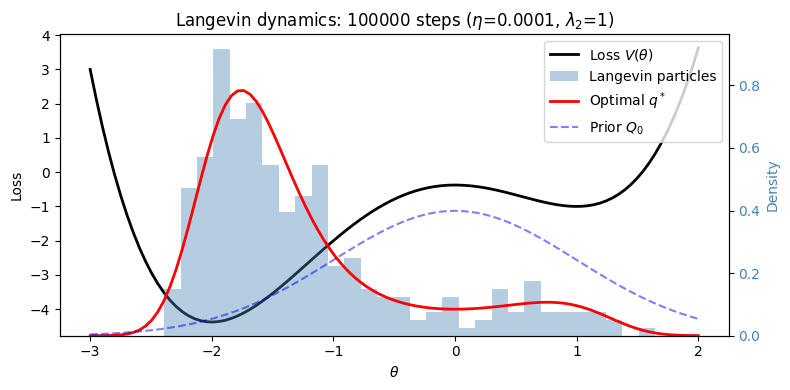

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(grid, loss_points, 'k-', lw=2, label='Loss $V(\\theta)$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Particle distribution on right axis
ax2 = ax1.twinx()
ax2.hist(particles_lang, bins=30, density=True, alpha=0.4, color='steelblue', label='Langevin particles')
ax2.plot(grid, optimal_vals, 'r-', lw=2, label=r'Optimal $q^*$')
ax2.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label='Prior $Q_0$')
ax2.set_ylabel('Density', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'Langevin dynamics: {K} steps ($\\eta$={eta}, $\\lambda_2$={lambda_2})')
plt.tight_layout()
plt.show()

#### Deep repulsive Langevin ensembles
Now we add the repulsive kernel interaction term:
$$+ \frac{\lambda_1}{2} \iint \kappa(\theta, \theta') dQ(\theta) dQ(\theta')$$
Using a RBF kernel $\kappa(\theta, \theta') = \exp\!\left(-\frac{|\theta - \theta'|^2}{2h^2}\right)$, the full Wasserstein gradient is now

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_1 \int (\nabla_1 \kappa)(\theta, \theta') \, dQ(\theta') + \lambda_2 \nabla \log q(\theta)$$

The kernel term acts as a **repulsive force** between particles. particles that are close together push each other apart. This helps explore multiple modes without relying solely on noise.

The particle update becomes:
$$\theta_n^{(k+1)} = \theta_n^{(k)} - \eta \left[\nabla V(\theta_n^{(k)}) + \frac{\lambda_1}{N_E} \sum_{m=1}^{N_E} \nabla_1 \kappa(\theta_n^{(k)}, \theta_m^{(k)})\right] + \sqrt{2\lambda_2 \eta}\, \xi_n^{(k)}, \quad \xi_n^{(k)} \sim N(0,1)$$

where the kernel gradient for the RBF is:
$$\nabla_1 \kappa(\theta, \theta') = -\frac{\theta - \theta'}{h^2} \kappa(\theta, \theta')$$

In [18]:
lambda_1 = 1.0

particles_drle = sample_prior(size=NE) # get particales 

# Get the sigma_k for the rbf as median of pairwise
pairwise_dists = np.abs(particles_drle[:, None] - particles_drle[None, :]) #NE * NE matrix
triu_dists = pairwise_dists[np.triu_indices(NE, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)

for t in tqdm(range(K)):

    ## repulsion
    diffs = particles_drle[:, None] - particles_drle[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    # Noise
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)

    # Update
    particles_drle = particles_drle - eta * (grad_V(particles_drle) + repulsion) + noise

  0%|          | 0/100000 [00:00<?, ?it/s]

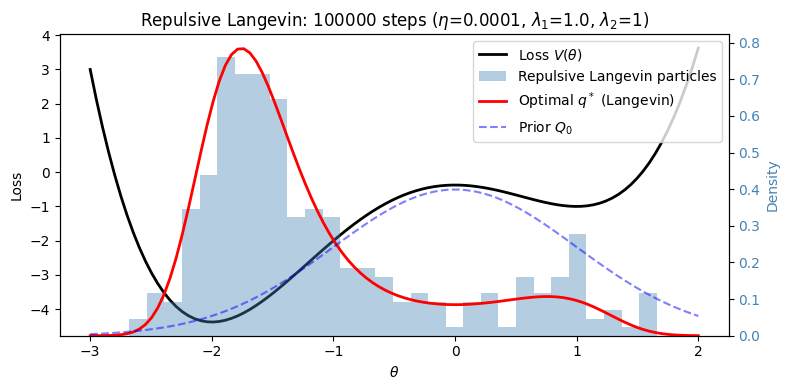

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(grid, loss_points, 'k-', lw=2, label='Loss $V(\\theta)$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Particle distribution on right axis
ax2 = ax1.twinx()
ax2.hist(particles_drle, bins=30, density=True, alpha=0.4, color='steelblue', label='Repulsive Langevin particles')
ax2.plot(grid, optimal_vals, 'r-', lw=2, label=r'Optimal $q^*$ (Langevin)')
ax2.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label='Prior $Q_0$')
ax2.set_ylabel('Density', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'Repulsive Langevin: {K} steps ($\\eta$={eta}, $\\lambda_1$={lambda_1}, $\\lambda_2$={lambda_2})')
plt.tight_layout()
plt.show()

### SVGD Varient test
swapped out the update step where now the gradient is weighted by the average particle repulsion

In [20]:
particles_drle_no_noise = sample_prior(size=NE) # get particales 
lambda_2 = 0
lambda_1 = 1

# Get the sigma_k for the rbf as median of pairwise
pairwise_dists = np.abs(particles_drle_no_noise[:, None] - particles_drle_no_noise[None, :]) #NE * NE matrix
triu_distats = pairwise_dists[np.triu_indices(NE, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)

for t in tqdm(range(K)):

    ## repulsion
    diffs = particles_drle_no_noise[:, None] - particles_drle_no_noise[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    # Noise
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)

    # Update
    grad_vals = grad_V(particles_drle_no_noise)                    # (NE,)  — gradient at each particle
    weighted_grad = (K_mat * grad_vals[:, None]).mean(axis=0)  # (NE,)

    particles_drle_no_noise = particles_drle_no_noise - eta * (weighted_grad + repulsion) + noise

  0%|          | 0/100000 [00:00<?, ?it/s]

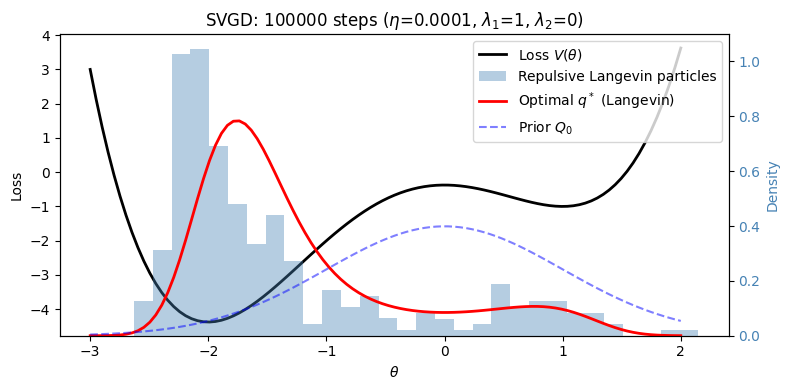

In [21]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(grid, loss_points, 'k-', lw=2, label='Loss $V(\\theta)$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Particle distribution on right axis
ax2 = ax1.twinx()
ax2.hist(particles_drle_no_noise, bins=30, density=True, alpha=0.4, color='steelblue', label='Repulsive Langevin particles')
ax2.plot(grid, optimal_vals, 'r-', lw=2, label=r'Optimal $q^*$ (Langevin)')
ax2.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label='Prior $Q_0$')
ax2.set_ylabel('Density', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'SVGD: {K} steps ($\\eta$={eta}, $\\lambda_1$={lambda_1}, $\\lambda_2$={lambda_2})')
plt.tight_layout()
plt.show()

### Solving the DRLE stationary distribution (G.1)

The stationary $q^*$ for DRLE satisfies $u(\theta) = \log q^*(\theta)$ where:

$$u'(\theta) = -\frac{1}{\lambda_2}V'(\theta) - \frac{\lambda_1}{\lambda_2}\int (\nabla_1 \kappa)(\theta, \theta') \exp(u(\theta'))\, d\theta'$$

>  equation (136) in Appendix G.1
> which is exactly setting $\nabla_W L^{\text{fe}}[Q](\theta) = 0$ and rearranging for $u' = \nabla \log q^*$

 solve this via fixed-point iteration: guess $u$, compute the integral, integrate $u'$ to get a new $u$, normalise, repeat.


In [22]:
def solve_drle_stationary(lambda_1, lambda_2, sigma_k=sigma_k, grid=np.linspace(-4, 3, 300), max_iter=50, tol=1e-8):
    dtheta = grid[1] - grid[0]
    grad_V = lambda theta: grad_loss(theta) + lambda_2 * theta

    # DLE closed form as starting guess
    V = lambda theta: loss(theta) - log_prior(theta)
    log_q_dle = -V(grid) / lambda_2
    log_q_dle -= np.log(trapezoid(np.exp(log_q_dle), grid))
    q_dle = np.exp(log_q_dle)

    # DRLE: iterative IDE solver
    u = log_q_dle.copy()
    for i in range(max_iter):
        exp_u = np.exp(u - u.max())
        grad_K = -(grid[:, None] - grid[None, :]) / sigma_k**2 \
                 * np.exp(-(grid[:, None] - grid[None, :])**2 / (2 * sigma_k**2))
        integral = trapezoid(grad_K * exp_u[None, :], grid, axis=1)
        u_prime = -(1/lambda_2) * grad_V(grid) - (lambda_1/lambda_2) * integral
        u_new = np.cumsum(u_prime) * dtheta
        u_new -= np.log(trapezoid(np.exp(u_new), grid))
        curr_score = np.max(np.abs(u_new - u))
        if curr_score < tol:
            # print(f"Converged at iteration {i}")
            break
        u = u_new

    return np.exp(u), q_dle, grid, curr_score

q_drle, q_dle, theta_grid, score = solve_drle_stationary(lambda_1=1.0, lambda_2=1.0)

In [23]:
lambda_range = np.linspace(0.1,2.5,25)
q_drles = []
for lambda_1 in lambda_range:
    q_drle, q_dle, theta_grid, score = solve_drle_stationary(lambda_1=lambda_1, lambda_2=1.0,max_iter=20000)
    # print(score)
    q_drles.append(q_drle)

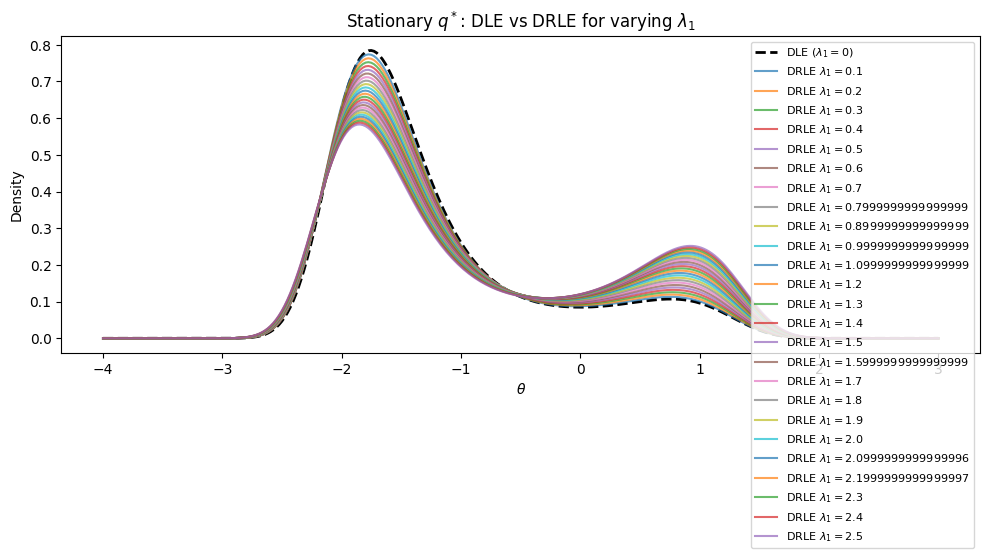

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(theta_grid, q_dle, 'k--', lw=2, label=r'DLE ($\lambda_1=0$)')
for lam1, drle in zip(lambda_range, q_drles):
    plt.plot(theta_grid, drle, lw=1.5, alpha=0.7, label=rf'DRLE $\lambda_1={lam1}$')

plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(r'Stationary $q^*$: DLE vs DRLE for varying $\lambda_1$')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

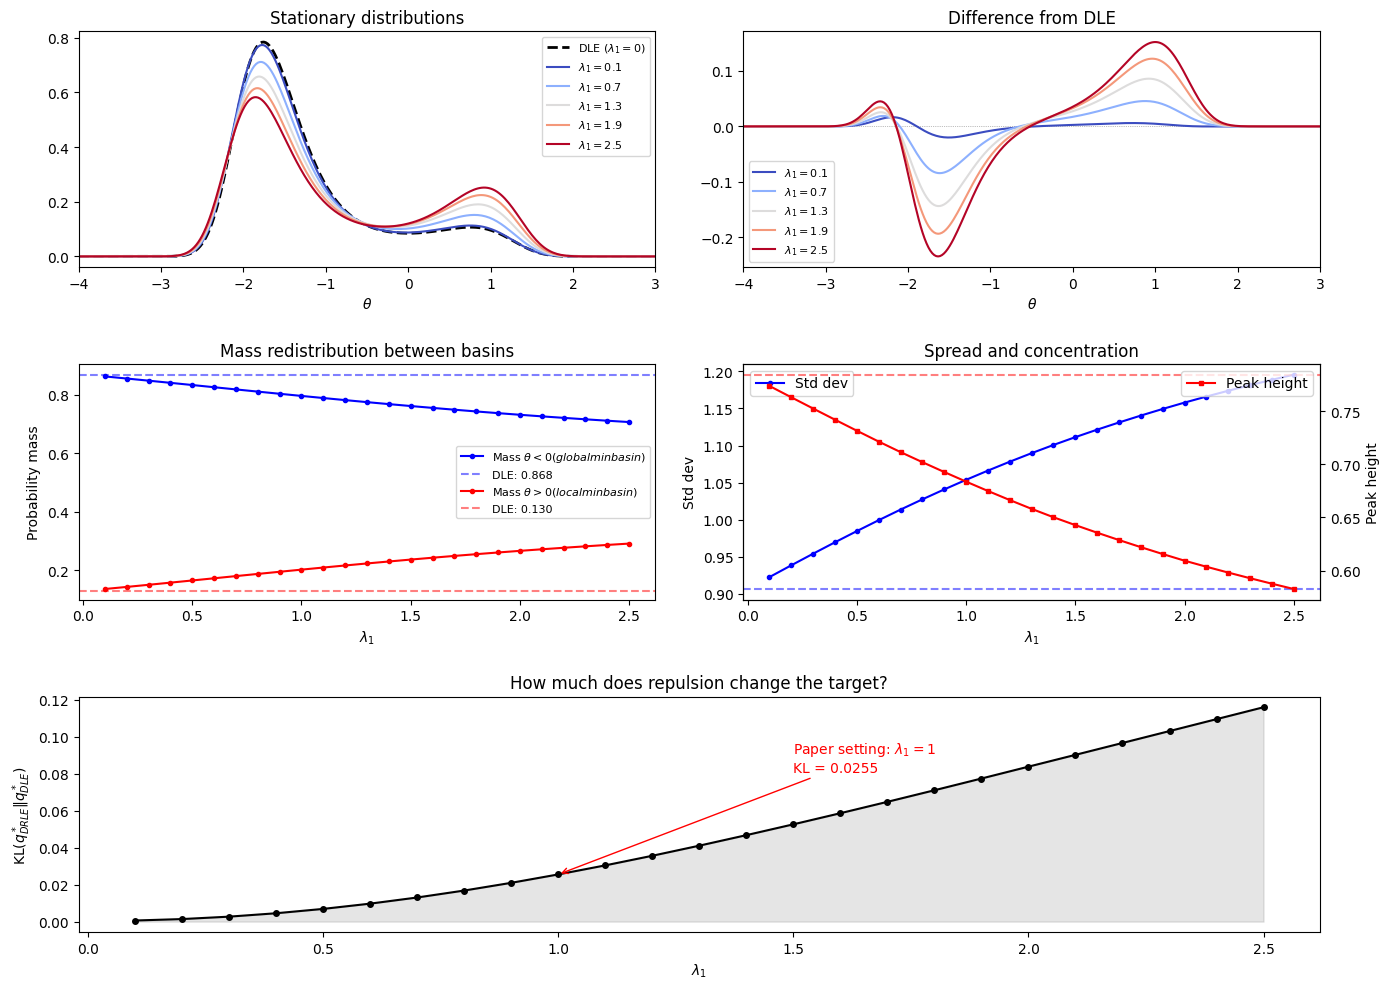

In [25]:
# 1. Vectorise calculations (removes the massive loop entirely)
Q = np.array(q_drles)
tg, zi = theta_grid, np.argmin(np.abs(theta_grid))

# Process all parameters at once using axis=1
modes, peaks = tg[np.argmax(Q, axis=1)], np.max(Q, axis=1)
mass_L, mass_R = trapezoid(Q[:, :zi], tg[:zi], axis=1), trapezoid(Q[:, zi:], tg[zi:], axis=1)
means = trapezoid(tg * Q, tg, axis=1)
stds = np.sqrt(trapezoid((tg - means[:, None])**2 * Q, tg, axis=1))

mask = (Q > 1e-15) & (q_dle > 1e-15)
kls = trapezoid(np.where(mask, Q * np.log(Q / q_dle), 0), tg, axis=1)

# 2. DLE baseline (condensed to just what you need)
dle_p, dle_L, dle_R = np.max(q_dle), trapezoid(q_dle[:zi], tg[:zi]), trapezoid(q_dle[zi:], tg[zi:])
dle_std = np.sqrt(trapezoid((tg - trapezoid(tg * q_dle, tg))**2 * q_dle, tg))

# ============================================================
# Plot (optimised)
# ============================================================
fig = plt.figure(figsize=(14, 10))
ax1, ax2, ax3, ax4 = [plt.subplot(3, 2, i) for i in range(1, 5)]
ax5 = plt.subplot(3, 2, (5, 6)) # Natively spans the bottom row

# Top row: Select distributions & Differences (Combined loop)
ax1.plot(tg, q_dle, 'k--', lw=2, label='DLE ($\\lambda_1=0$)')
ax2.axhline(0, color='gray', lw=0.5, ls=':')
for i, c in zip([0, 6, 12, 18, 24], plt.cm.coolwarm(np.linspace(0, 1, 5))):
    lbl = f'$\\lambda_1={lambda_range[i]:.1f}$'
    ax1.plot(tg, Q[i], color=c, lw=1.5, label=lbl)
    ax2.plot(tg, Q[i] - q_dle, color=c, lw=1.5, label=lbl)
for ax, title in zip([ax1, ax2], ['Stationary distributions', 'Difference from DLE']):
    ax.set(xlabel=r'$\theta$', title=title, xlim=(-4, 3)); ax.legend(fontsize=8)

# Middle left: Mass redistribution
for y, dy, c, l in [(mass_L, dle_L, 'b', '< 0 (global min basin)'), (mass_R, dle_R, 'r', '> 0 (local min basin)')]:
    ax3.plot(lambda_range, y, f'{c}-o', ms=3, label=f'Mass $\\theta {l}$')
    ax3.axhline(dy, color=c, ls='--', alpha=0.5, label=f'DLE: {dy:.3f}')
ax3.set(xlabel=r'$\lambda_1$', ylabel='Probability mass', title='Mass redistribution between basins'); ax3.legend(fontsize=8)

# Middle right: Spread and concentration
ax4.plot(lambda_range, stds, 'b-o', ms=3, label='Std dev')
ax4.axhline(dle_std, color='b', ls='--', alpha=0.5)
ax4_2 = ax4.twinx()
ax4_2.plot(lambda_range, peaks, 'r-s', ms=3, label='Peak height')
ax4_2.axhline(dle_p, color='r', ls='--', alpha=0.5)
ax4.set(xlabel=r'$\lambda_1$', ylabel='Std dev', title='Spread and concentration'); ax4_2.set_ylabel('Peak height')
ax4.legend(loc='upper left'); ax4_2.legend(loc='upper right')

# Bottom: KL divergence
ax5.plot(lambda_range, kls, 'k-o', ms=4)
ax5.fill_between(lambda_range, 0, kls, alpha=0.1, color='k')
ax5.set(xlabel=r'$\lambda_1$', ylabel=r'KL$(q^*_{DRLE} \| q^*_{DLE})$', title='How much does repulsion change the target?')

pidx = np.argmin(np.abs(lambda_range - 1.0))
ax5.annotate(f'Paper setting: $\\lambda_1=1$\nKL = {kls[pidx]:.4f}', (lambda_range[pidx], kls[pidx]),
             xytext=(1.5, max(kls) * 0.7), arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.tight_layout(h_pad=2.0, w_pad=2.0)

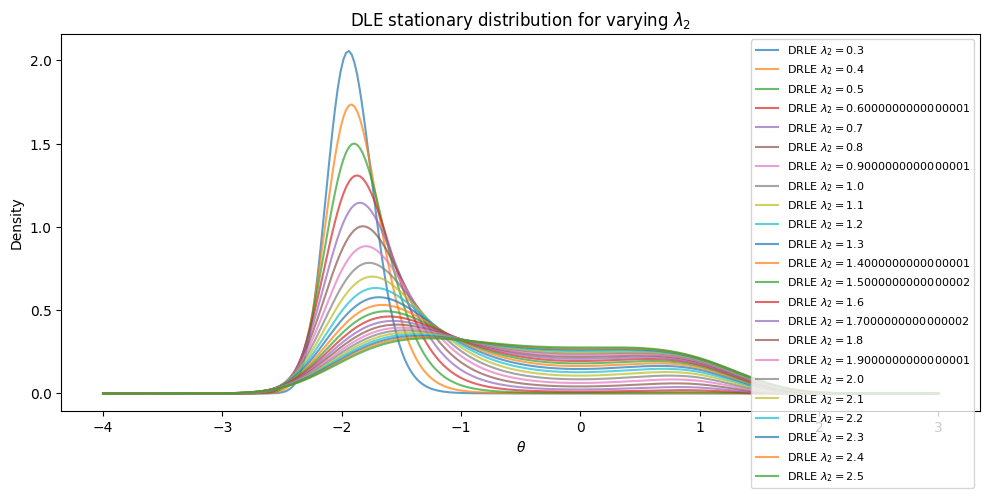

In [26]:
lambda_range = np.linspace(0.3,2.5,23)
q_drles = []
for lambda_1 in lambda_range:
    q_drle, q_dle, theta_grid, score = solve_drle_stationary(lambda_1=0, lambda_2=lambda_1,max_iter=20000)
    # print(score)
    q_drles.append(q_drle)

plt.figure(figsize=(10, 5))
# plt.plot(theta_grid, q_dle, 'k--', lw=2, label=r'DLE ($\lambda_1=0$)')
for lam1, drle in zip(lambda_range, q_drles):
    plt.plot(theta_grid, drle, lw=1.5, alpha=0.7, label=rf'DRLE $\lambda_2={lam1}$')

plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(r'DLE stationary distribution for varying $\lambda_2$')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Convergence speeds

In [27]:
# Pre-compute the true stationary distributions
lambda_1 = lambda_2 = 1

q_drle_true, q_dle_true, theta_grid, _ = solve_drle_stationary(lambda_1=lambda_1, lambda_2=lambda_2)

particles_lang = sample_prior(size=NE)
particles_drle = sample_prior(size=NE)

check_every = 200
kl_dle_hist = []
kl_drle_hist = []
steps = []

for t in tqdm(range(K)):
    # DLE update
    noise_l = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_lang = particles_lang - eta * grad_V(particles_lang) + noise_l

    # DRLE update
    diffs = particles_drle[:, None] - particles_drle[None, :]
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))
    grad_K = -diffs / sigma_k**2 * K_mat
    repulsion = lambda_1 * grad_K.mean(axis=1)
    noise_r = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_drle = particles_drle - eta * (grad_V(particles_drle) + repulsion) + noise_r

    if (t + 1) % check_every == 0:
        # KDE of particles, evaluate on grid
        kde_dle = gaussian_kde(particles_lang)(theta_grid)
        kde_drle = gaussian_kde(particles_drle)(theta_grid)

        # KL(kde || true)
        mask_dle = (kde_dle > 1e-15) & (q_dle_true > 1e-15)
        kl_dle = trapezoid(np.where(mask_dle, kde_dle * np.log(kde_dle / q_dle_true), 0), theta_grid)

        mask_drle = (kde_drle > 1e-15) & (q_drle_true > 1e-15)
        kl_drle = trapezoid(np.where(mask_drle, kde_drle * np.log(kde_drle / q_drle_true), 0), theta_grid)

        kl_dle_hist.append(kl_dle)
        kl_drle_hist.append(kl_drle)
        steps.append(t + 1)

  0%|          | 0/100000 [00:00<?, ?it/s]

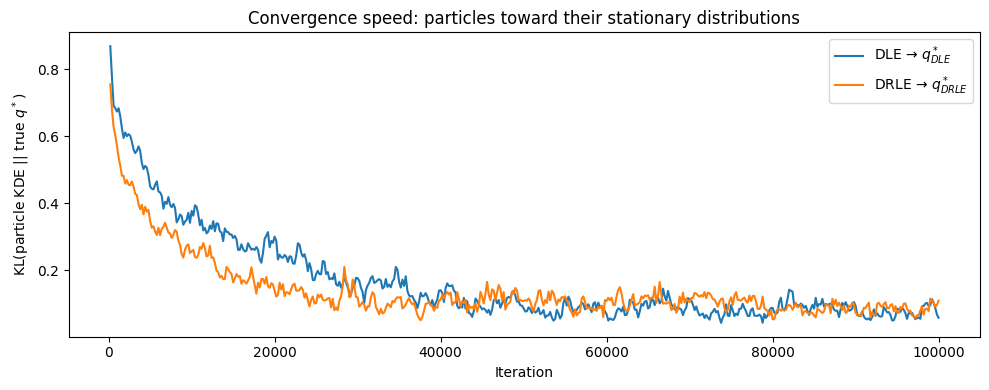

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(steps, kl_dle_hist, label='DLE → $q^*_{DLE}$')
plt.plot(steps, kl_drle_hist, label='DRLE → $q^*_{DRLE}$')
plt.xlabel('Iteration')
plt.ylabel('KL(particle KDE || true $q^*$)')
plt.title('Convergence speed: particles toward their stationary distributions')
plt.legend()
plt.tight_layout()
plt.show()

## G.2 Example with multiple modes 

In [ ]:

# 2D, 4 modes
mus = np.array([[3,3], [-3,3], [-3,-3], [3,-3]])

def loss_g2(theta):  # theta shape (NE, 2)
    pdf = sum(0.25 * multivariate_normal.pdf(theta, mu, np.eye(2)) for mu in mus)
    return -np.log(pdf + 1e-300)

def grad_loss_g2(theta):  # finite differences or analytical
    eps = 1e-5
    g = np.zeros_like(theta)
    for d in range(2):
        theta_p = theta.copy(); theta_p[:, d] += eps
        theta_m = theta.copy(); theta_m[:, d] -= eps
        g[:, d] = (loss_g2(theta_p) - loss_g2(theta_m)) / (2 * eps)
    return g

# Flat prior, so grad_V = grad_loss
grad_V_g2 = grad_loss_g2

prior_dist_g2 = multivariate_normal(np.zeros(2), np.eye(2))
sample_prior_g2 = lambda size: prior_dist_g2.rvs(size)

NE_g2 = 300
eta_g2 = 0.1
K_g2 = 10000
lambda_1 = 0.6   # λ_DRLE
lambda_2 = 0.2   # λ'_DRLE (the noise/KL term)

"Note that for a flat prior $P.. \nabla V$ is the same for all three methods since $\log p$
and $\mu_P$
​ are constant."

In [ ]:
sample_prior = prior_dist_g2.rvs
d_particles = sample_prior(size=NE_g2)
particles_lang = sample_prior(size=NE_g2)
particles_drle = sample_prior(size=NE_g2) # get particales 


pairwise_dists = np.abs(particles_drle[:, None] - particles_drle[None, :]) #NE * NE matrix
triu_dists = pairwise_dists[np.triu_indices(NE_g2, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)


for t in tqdm(range(K_g2)):
    d_particles += -eta_g2 * grad_loss_g2(d_particles) 

    noise = np.random.randn(NE_g2, 2) * np.sqrt(2 * lambda_2 * eta_g2)

    ## repulsion
    diffs = particles_drle[:, None] - particles_drle[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    particles_lang += - eta_g2 * grad_V_g2(particles_lang) + noise
    particles_drle += - eta_g2 * (grad_V_g2(particles_drle) + repulsion) + noise

  0%|          | 0/10000 [00:00<?, ?it/s]

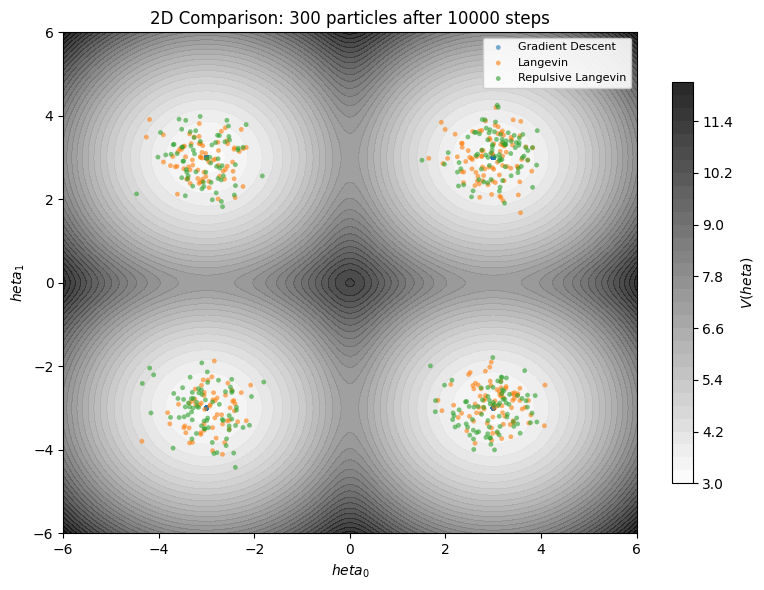

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
Z = loss_g2(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

cs = ax.contourf(X, Y, Z, levels=30, cmap='gray_r', alpha=0.85)
fig.colorbar(cs, ax=ax, label=r'$V(	heta)$', shrink=0.8)

ax.scatter(d_particles[:, 0], d_particles[:, 1], s=12, alpha=0.6,
           color='tab:blue', edgecolors='none', label='Gradient Descent')
ax.scatter(particles_lang[:, 0], particles_lang[:, 1], s=12, alpha=0.6,
           color='tab:orange', edgecolors='none', label='Langevin')
ax.scatter(particles_drle[:, 0], particles_drle[:, 1], s=12, alpha=0.6,
           color='tab:green', edgecolors='none', label='Repulsive Langevin')

# for i, mu in enumerate(mus):
    # ax.plot(*mu, 'r+', ms=14, mew=2.5, label='Mode centres' if i == 0 else None)

ax.set_xlabel(r'$	heta_0$')
ax.set_ylabel(r'$	heta_1$')
ax.set_title(f'2D Comparison: {NE_g2} particles after {K_g2} steps')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## Same again with skewed prior

In [ ]:
mus = np.array([[3,3], [-3,3], [-3,-3], [3,-3]])
prior_mu = np.array([-3, 3])
prior_var = 9.0

# Loss: negative log of equal-weight Gaussian mixture
def loss_g2(theta):
    pdf = sum(0.25 * multivariate_normal.pdf(theta, mu, np.eye(2)) for mu in mus)
    return -np.log(pdf + 1e-300)

def grad_loss_g2(theta):  # (NE, 2)
    pdfs = np.stack([0.25 * multivariate_normal.pdf(theta, mu, np.eye(2)) for mu in mus], axis=1)  # (NE, 4)
    weights = pdfs / pdfs.sum(axis=1, keepdims=True)  # (NE, 4) — responsibility of each mode
    return sum(weights[:, i, None] * (theta - mus[i]) for i in range(4))

# Prior: N([-3,3], 9I)
prior_dist_g2 = multivariate_normal(prior_mu, prior_var * np.eye(2))
sample_prior_g2 = lambda size: prior_dist_g2.rvs(size)
grad_log_prior_g2 = lambda theta: -(theta - prior_mu) / prior_var

# Potential: V(θ) = ℓ(θ) - λ₂ log p(θ)
grad_V_g2 = lambda theta: grad_loss_g2(theta) - lambda_2 * grad_log_prior_g2(theta)

# Hyperparameters
NE_g2 = 300
eta_g2 = 0.1
K_g2 = 10000
lambda_1 = 1  # repulsion (MMD)
lambda_2 = 0.6  # noise/entropy (KL)

In [ ]:
sample_prior = prior_dist_g2.rvs
d_particles = sample_prior(size=NE_g2)
particles_lang = sample_prior(size=NE_g2)
particles_drle = sample_prior(size=NE_g2) # get particales 


pairwise_dists = np.abs(particles_drle[:, None] - particles_drle[None, :]) #NE * NE matrix
triu_dists = pairwise_dists[np.triu_indices(NE_g2, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)


for t in tqdm(range(K_g2)):
    d_particles += -eta_g2 * grad_loss_g2(d_particles) 

    noise = np.random.randn(NE_g2, 2) * np.sqrt(2 * lambda_2 * eta_g2)

    ## repulsion
    diffs = particles_drle[:, None] - particles_drle[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    particles_lang += - eta_g2 * grad_V_g2(particles_lang) + noise
    particles_drle += - eta_g2 * (grad_V_g2(particles_drle) + repulsion) + noise

  0%|          | 0/10000 [00:00<?, ?it/s]

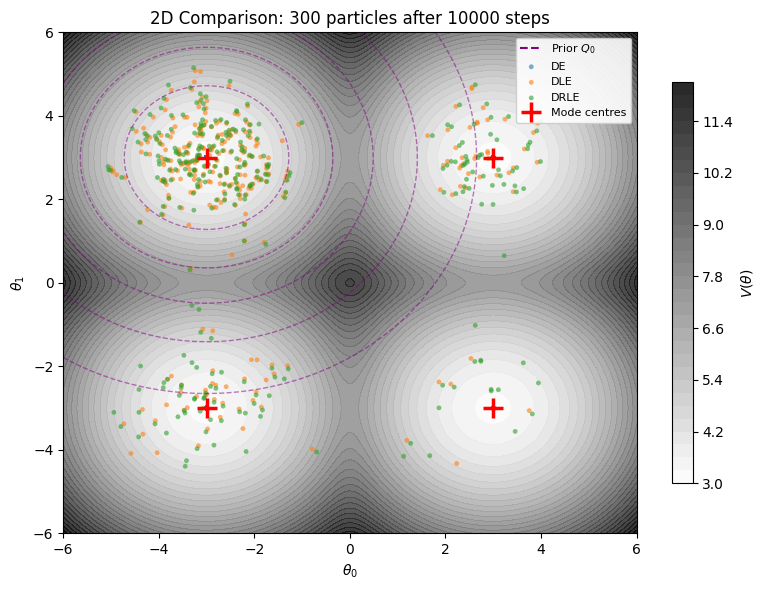

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
Z = loss_g2(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

cs = ax.contourf(X, Y, Z, levels=30, cmap='gray_r', alpha=0.85)
fig.colorbar(cs, ax=ax, label=r'$V(\theta)$', shrink=0.8)

# Prior contours
Z_prior = prior_dist_g2.pdf(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)
ax.contour(X, Y, Z_prior, levels=5, colors='purple', alpha=0.5, linestyles='--', linewidths=1)
ax.plot([], [], 'purple', ls='--', label=r'Prior $Q_0$')

ax.scatter(d_particles[:, 0], d_particles[:, 1], s=12, alpha=0.6,
           color='tab:blue', edgecolors='none', label='DE')
ax.scatter(particles_lang[:, 0], particles_lang[:, 1], s=12, alpha=0.6,
           color='tab:orange', edgecolors='none', label='DLE')
ax.scatter(particles_drle[:, 0], particles_drle[:, 1], s=12, alpha=0.6,
           color='tab:green', edgecolors='none', label='DRLE')

for i, mu in enumerate(mus):
    ax.plot(*mu, 'r+', ms=14, mew=2.5, label='Mode centres' if i == 0 else None)

ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(f'2D Comparison: {NE_g2} particles after {K_g2} steps')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

Mode           DE    DLE   DRLE
--------------------------------
(3,3)          41     37     52
(-3,3)        215    215    174
(-3,-3)        35     42     57
(3,-3)          9      6     17


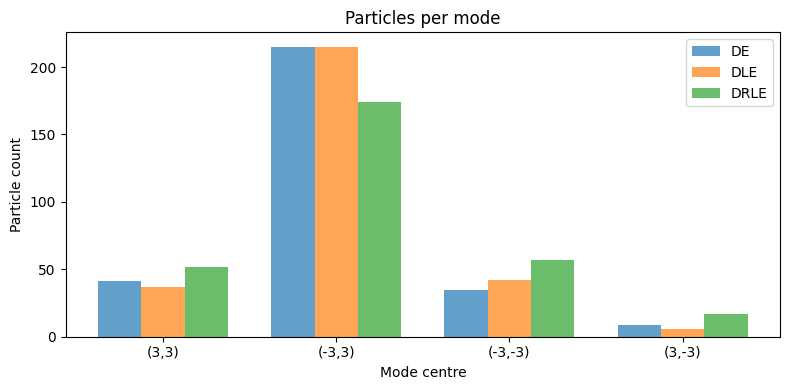

In [ ]:
# 1. Optimised counting function using bincount
def count_modes(particles, mus):
    dists = np.linalg.norm(particles[:, None, :] - mus[None, :, :], axis=2)
    return np.bincount(np.argmin(dists, axis=1), minlength=len(mus))

# 2. Process data ONCE into a dictionary
datasets = {'DE': d_particles, 'DLE': particles_lang, 'DRLE': particles_drle}
counts = {name: count_modes(pts, mus) for name, pts in datasets.items()}
labels = [f'({mu[0]},{mu[1]})' for mu in mus]

# 3. Print the table
print(f"{'Mode':<10} {'DE':>6} {'DLE':>6} {'DRLE':>6}\n" + "-" * 32)
for i, lbl in enumerate(labels):
    print(f"{lbl:<10} {counts['DE'][i]:>6} {counts['DLE'][i]:>6} {counts['DRLE'][i]:>6}")

# 4. Plot using a loop
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))

for i, (name, cnt) in enumerate(counts.items()):
    ax.bar(x + (i - 1) * 0.25, cnt, 0.25, label=name, alpha=0.7)

ax.set(xticks=x, xticklabels=labels, xlabel='Mode centre', ylabel='Particle count', title='Particles per mode')
ax.legend(); plt.tight_layout(); plt.show()

Generalised bayes test
$$Q_n^\dagger = \arg\min_{Q \in \mathcal{P}(\Theta)} \int L_n(\theta, y_{1:n}) , dQ(\theta) + \lambda_n , \text{KL}(Q, Q_0)$$

In [30]:
# --- Ground truth: data from a misspecified model ---
np.random.seed(42)
n = 150
data = np.concatenate([
    np.random.normal(-3, 1, n // 2),
    # np.random.normal(3, 1, n // 2)
])

# --- Model: P_theta = N(theta, 1) ---
# L_n(theta) = 0.5 * sum_i (y_i - theta)^2
# grad w.r.t. theta: sum_i (theta - y_i) = n*theta - sum(y_i)
loss = lambda theta: 0.5 * np.sum((data[:, None] - theta[None, :])**2, axis=0)
grad_loss = lambda theta: np.sum(theta[None, :] - data[:, None], axis=0)

# V(theta) = L(theta) + 0.5*theta^2  (prior term)
grad_V = lambda theta: grad_loss(theta) + theta

prior_dist = stats.norm(0, 1)
prior = prior_dist.pdf
log_prior = prior_dist.logpdf

sum_data = np.sum(data)
grad_loss_fast = lambda theta: n * theta - sum_data
grad_V_fast = lambda theta: grad_loss_fast(theta) + theta  # = (n+1)*theta - sum_data

NE = 500
eta = 1e-7
K = 100000

In [31]:
sample_prior = prior_dist.rvs
particles_lang = sample_prior(size=NE)

In [32]:
sum_data = np.sum(data)
grad_loss_fast = lambda theta: n * theta - sum_data
grad_V_fast = lambda theta: grad_loss_fast(theta) + theta  # = (n+1)*theta - sum_data

# grad_V = (n+1)*theta - sum_data
coeff = n + 1
for t in tqdm(range(K)):
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_lang = particles_lang - eta * (coeff * particles_lang - sum_data) + noise

  0%|          | 0/100000 [00:00<?, ?it/s]

### MMD 
Generalised bayes
$$Q_n^\dagger = \arg\min_{Q \in \mathcal{P}(\Theta)} \int L_n(\theta, y_{1:n})  dQ(\theta) + \lambda_n , \text{KL}(Q, Q_0)$$



Generalised Bayes: score each θ on its own.

$L(\theta) = -\sum_{i=1}^{n} \log p_{\theta}(y_i)$
then average over $Q$.

------
PCUQ: score the mixture collectively.

$$L(Q) = \text{MMD}^2 \left( P_n, \frac{1}{N} \sum_{j=1}^{N} P_{\theta^j} \right)$$
>$P_n = \frac{1}{n} \sum_{i=1}^{n} \delta_{y_i}$.

This can replace the loss function in the original generalised bayes:
$$\int L_n(\theta, y_{1:n}) dQ(\theta) \text{  is now  } \frac{1}{2}MMD^2(P_n, P_Q)$$
giving out total Q_n as 
$$Q_n = \arg \min_{Q \in \mathcal{P}(\Theta)} \frac{1}{2} \text{MMD}^2(P_n, P_Q) + \lambda_n \text{KL}(Q, Q_0)$$

Note: (for a single model)
$$\text{MMD}^2(P_n, P_{\theta}) = \underbrace{\mathbb{E}_{y,y' \sim P_n}[k(y,y')]}_{\text{data vs data}} - 2\underbrace{\mathbb{E}_{y \sim P_n, z \sim P_{\theta}}[k(y,z)]}_{\text{data vs model}} + \underbrace{\mathbb{E}_{z,z' \sim P_{\theta}}[k(z,z')]}_{\text{model vs model}}$$

bellow example mean of data vs data kernel

In [33]:
mmd_data_points = [(2, 1), (-2, 1)]
mmd_data = np.concatenate([stats.norm.rvs(size=50, scale=s, loc=l) for (l,s) in mmd_data_points])
locs = np.array([p[0] for p in mmd_data_points])
scales = np.array([p[1] for p in mmd_data_points])

mmd_data_pdf = lambda x: np.sum(stats.norm.pdf(x[:, np.newaxis], loc=locs, scale=scales), axis=1)
rbf_sigma = 1
rbf_kernel = lambda x, y: np.exp(-np.square(np.abs(x - y)) / (2 * rbf_sigma**2))

# Sort so axes are ordered by value
order = np.argsort(mmd_data)
mmd_sorted = mmd_data[order]
K_mat = rbf_kernel(mmd_sorted, mmd_sorted[:, np.newaxis])

C:\Users\samue\AppData\Local\Temp\ipykernel_44740\2995394040.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


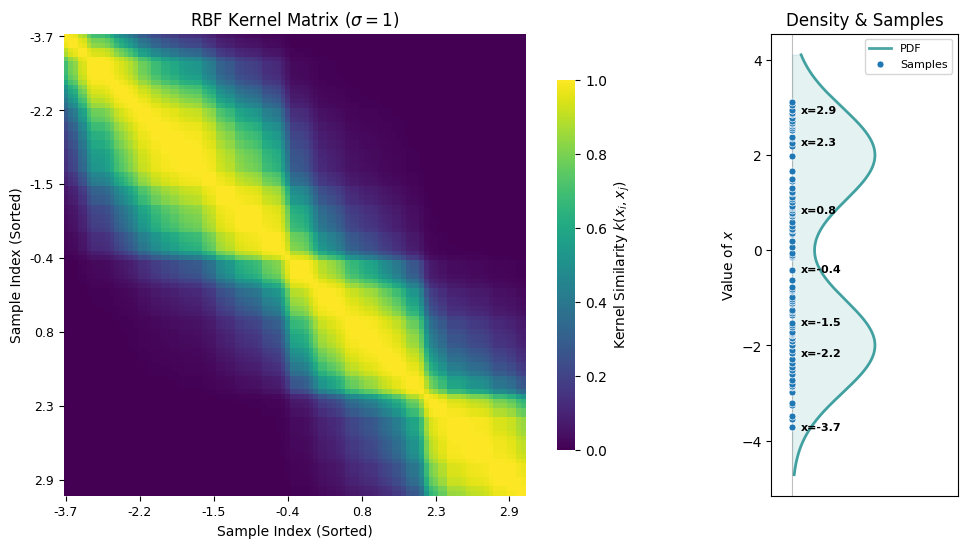

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), 
                         gridspec_kw={"width_ratios": [5, 1.5], "wspace": 0.3})

# --- Heatmap ---
tick_step = max(1, len(mmd_sorted) // 6)
tick_idx = list(range(0, len(mmd_sorted), tick_step))
tick_labels = [f"{mmd_sorted[i]:.1f}" for i in tick_idx]

sns.heatmap(K_mat, ax=axes[0], cmap="viridis", square=True,
            cbar_kws={"label": r"Kernel Similarity $k(x_i, x_j)$", "shrink": 0.8},
            xticklabels=False, yticklabels=False)

axes[0].set_xticks([i + 0.5 for i in tick_idx])
axes[0].set_xticklabels(tick_labels, fontsize=9)
axes[0].set_yticks([i + 0.5 for i in tick_idx])
axes[0].set_yticklabels(tick_labels, fontsize=9)
axes[0].set_xlabel("Sample Index (Sorted)")
axes[0].set_ylabel("Sample Index (Sorted)")
axes[0].set_title(rf"RBF Kernel Matrix ($\sigma = {rbf_sigma}$)")

# --- Data scatter + PDF (Vertical) ---
# 1. Plot the PDF curve (x-axis is density, y-axis is value)
y_range = np.linspace(mmd_sorted.min() - 1, mmd_sorted.max() + 1, 500)
pdf_values = mmd_data_pdf(y_range)

# Scaling PDF for visibility on the plot (purely for aesthetic alignment)
pdf_scale = 0.5 
axes[1].plot(pdf_values * pdf_scale, y_range, color="teal", alpha=0.7, lw=2, label="PDF")
axes[1].fill_betweenx(y_range, 0, pdf_values * pdf_scale, color="teal", alpha=0.1)

# 2. Plot the actual scatter points
axes[1].scatter(np.zeros_like(mmd_sorted), mmd_sorted, s=25,
                color="tab:blue", edgecolors="white", linewidths=0.5, zorder=3, label="Samples")

axes[1].axvline(0, color="grey", lw=0.8, alpha=0.5)

# 3. Add labels to specific points
for i in tick_idx:
    val = mmd_sorted[i]
    axes[1].text(0.02, val, f"x={val:.1f}", 
                 fontsize=8, verticalalignment='center', fontweight='bold')

axes[1].set_xlim(-0.05, pdf_values.max() * pdf_scale + 0.2)
axes[1].set_ylabel("Value of $x$")
axes[1].set_xticks([])
axes[1].set_title("Density & Samples")
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


$$E_{x, x' \sim P} [k(x, x')] \approx \frac{1}{n^2} \sum_{i=1}^{n} \sum_{j=1}^{n} K_{ij}$$

In [35]:
# Biased estimator (includes the diagonal k(xi, xi) = 1)
expected_val = np.mean(K_mat)

print(f"Empirical Mean Kernel: E_{{x, x' ~ P}}[k(x, x')] ≈ {expected_val:.4f}")

# Sum of all elements minus the diagonal, divided by N*(N-1)
unbiased_mean = (np.sum(K_mat) - np.trace(K_mat)) / (len(mmd_sorted) * (len(mmd_sorted) - 1))

print(f"Empirical Mean Kernel (Unbiased): E_{{x, x' ~ P}}[k(x, x')] ≈ {unbiased_mean:.4f}")


Empirical Mean Kernel: E_{x, x' ~ P}[k(x, x')] ≈ 0.3285
Empirical Mean Kernel (Unbiased): E_{x, x' ~ P}[k(x, x')] ≈ 0.3218


$$\mu_k(P) = \mathbb{E}_{y \sim P} [k(\cdot, y)] = \int_{\mathcal{X}} k(\cdot, y) \, dP(y)$$

Given a set of $n$ samples $\{y_1, \dots, y_n\}$ drawn i.i.d. from $P$, the Empirical Kernel Mean Embedding is the sample average:$$\mu_k(P_n) = \frac{1}{n} \sum_{i=1}^{n} k(\cdot, y_i)$$

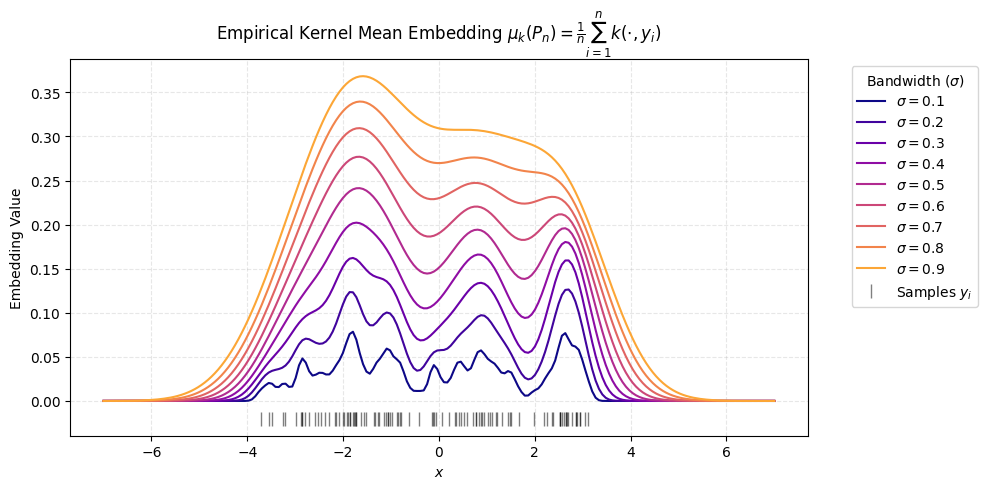

In [36]:
grid = np.linspace(-7, 7, 200)
n = len(mmd_data)
colors = plt.cm.plasma(np.linspace(0, 0.8, 9)) # Using plasma for better contrast

plt.figure(figsize=(10, 5))

for i, s in enumerate(range(1, 10)):
    rbf_sigma = s / 10
    
    K_grid = rbf_kernel(grid[:, np.newaxis], mmd_data)
    mu_kn = np.mean(K_grid, axis=1) 
    
    plt.plot(grid, mu_kn, label=rf"$\sigma = {rbf_sigma}$", color=colors[i], lw=1.5)

# Add a rug plot of the actual samples
plt.plot(mmd_data, np.zeros_like(mmd_data) - 0.02, '|', color='k', ms=10, alpha=0.5, label='Samples $y_i$')
plt.title(r"Empirical Kernel Mean Embedding $\mu_k(P_n) = \frac{1}{n} \sum_{i=1}^n k(\cdot, y_i)$")
plt.xlabel("$x$")
plt.ylabel("Embedding Value")
plt.legend(title="Bandwidth ($\sigma$)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The Residual. define the residual function:$$r(\theta) = \mu_k(P_n) - \mu_k(P_\theta)$$

- Positive values of $r(\theta)(x)$ indicate regions where there is more data than the model predicts (underfitting).
- Negative values indicate regions where the model allocates too much probability mass relative to the actual data (overfitting).

The squared RKHS norm of this residual is exactly the squared Maximum Mean Discrepancy (MMD):$$\|r(\theta)\|_{\mathcal{H}}^2 = MMD^2(P_n, P_\theta)$$

The Residual Inner Product$$\kappa_{P_n}(\theta, \vartheta) = \langle \mu_k(P_n) - \mu_k(P_\theta), \mu_k(P_n) - \mu_k(P_\vartheta) \rangle_{\mathcal{H}(k)}$$
which can then be expanded to DvD - DvM1 - DvM2 + M2vM1
$$\text{MMD}^2(P_n, P_Q) = \iint_{\Theta} \kappa_{P_n}(\theta, \vartheta) \, dQ(\theta) \, dQ(\vartheta)$$

$$ F_n(Q) = \frac{1}{2} \text{MMD}^2(P_n, P_Q) + \lambda_n \int_{\Theta} q(\theta) \log \left( \frac{q(\theta)}{\pi(\theta)} \right) \, d\theta $$
(eqn 7 from mmd paper, note they use 'free energy' which splits the entropy term out). i.e.

$Q_n$ of the proposed PCUQ method is a minimiser of the entropy-regularised objective$$F_n(Q) = \mathcal{E}_n(Q) + \lambda_n \int \log q(\theta) \, dQ(\theta), \qquad (7)$$where the free energy $\mathcal{E}_n(Q)$ is identical, after algebraic manipulation, to$$\mathcal{E}_n(Q) \overset{+C}{=} \int v(\theta) \, dQ(\theta) + \frac{1}{2} \iint \kappa_{P_n}(\theta, \vartheta) \, dQ(\theta) \, dQ(\vartheta),$$where $v(\theta) = -\lambda_n \log q_0(\theta)$, and where $q$ and $q_0$ are respectively densities for $Q$ and $Q_0$.

In [105]:
# --- Data: mixture of two Gaussians (misspecified for a single Gaussian model) ---
np.random.seed(42)
n = 50
data = np.concatenate([
    np.random.normal(-3, 1, n // 2),
    np.random.normal(3, 1, n // 2)
])

# --- Model: P_theta = N(theta, sigma^2) with known sigma ---
sigma = 1.0       # model noise
ell = 1.5          # kernel bandwidth
lambda_n = 0.1     

# --- Precompute constants ---
# For Gaussian kernel k(y,y') = exp(-|y-y'|^2 / (2*ell^2))
# and Gaussian model P_theta = N(theta, sigma^2):
#
# E_{P_n, P_theta}[k] = (1/n) sum_i  ell/s1 * exp(-|y_i - theta|^2 / (2*s1^2))
#   where s1 = sqrt(ell^2 + sigma^2)
#
# E_{P_theta, P_vartheta}[k] = ell/s2 * exp(-|theta - vartheta|^2 / (2*s2^2))
#   where s2 = sqrt(ell^2 + 2*sigma^2)

s1 = np.sqrt(ell**2 + sigma**2)
s2 = np.sqrt(ell**2 + 2 * sigma**2)
c1 = ell / s1
c2 = ell / s2

def cross_term(theta):
    """E_{P_n, P_theta}[k] for each particle. Shape: (NE,)"""
    # data[:, None] is (n, 1), theta[None, :] is (1, NE)
    sq = (data[:, None] - theta[None, :]) ** 2
    return c1 * np.mean(np.exp(-sq / (2 * s1**2)), axis=0)

def grad_cross_term(theta):
    """d/dtheta of E_{P_n, P_theta}[k]. Shape: (NE,)"""
    diff = theta[None, :] - data[:, None]  # (n, NE)
    sq = diff ** 2
    vals = c1 * np.exp(-sq / (2 * s1**2))
    return -np.mean(vals * diff / s1**2, axis=0)

def model_model(theta):
    """E_{P_theta, P_vartheta}[k] matrix. Shape: (NE, NE)"""
    diffs = theta[:, None] - theta[None, :]
    return c2 * np.exp(-diffs**2 / (2 * s2**2))

def grad_model_model(theta):
    """d/dtheta_i of E_{P_theta_i, P_theta_j}[k]. Shape: (NE, NE)"""
    diffs = theta[:, None] - theta[None, :]  # (NE, NE)
    mm = c2 * np.exp(-diffs**2 / (2 * s2**2))
    return -mm * diffs / s2**2

In [106]:
# --- Prior: Q_0 = N(0, 1) ---
# v(theta) = -lambda_n * log q_0(theta) = lambda_n * 0.5 * theta^2 + const
# grad_v(theta) = lambda_n * theta
grad_v = lambda theta: lambda_n * theta

# --- Particle setup ---
NE = 20
eta = 1e-3
K = 90000

lambda_n = 0.01   # less entropy -> tighter clusters

In [107]:
particles = np.random.randn(NE)  # init from prior N(0,1)

history = [particles.copy()]

for t in tqdm(range(K)):
    # Gradient of prior term
    gv = grad_v(particles)  # (NE,)

    # Gradient of Stein kernel interaction
    # kappa_{P_n}(theta_i, theta_j) has gradient w.r.t. theta_i:
    #   = -grad_cross(theta_i) + (1/N-1) sum_{j!=i} grad_mm(theta_i, theta_j)
    # (the data-vs-data term is constant, so no gradient)

    g_cross = grad_cross_term(particles)          # (NE,)
    g_mm = grad_model_model(particles)             # (NE, NE)

    # Zero out diagonal and average over other particles
    np.fill_diagonal(g_mm, 0)
    interaction = g_mm.sum(axis=1) / (NE - 1)     # (NE,)

    # Full drift: grad_v + grad of kernel terms
    drift = gv - g_cross + interaction

    # Noise
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_n * eta)

    # Update
    particles = particles - eta * drift + noise

    if t % 1000 == 0:
        history.append(particles.copy())

history.append(particles.copy())

  0%|          | 0/90000 [00:00<?, ?it/s]

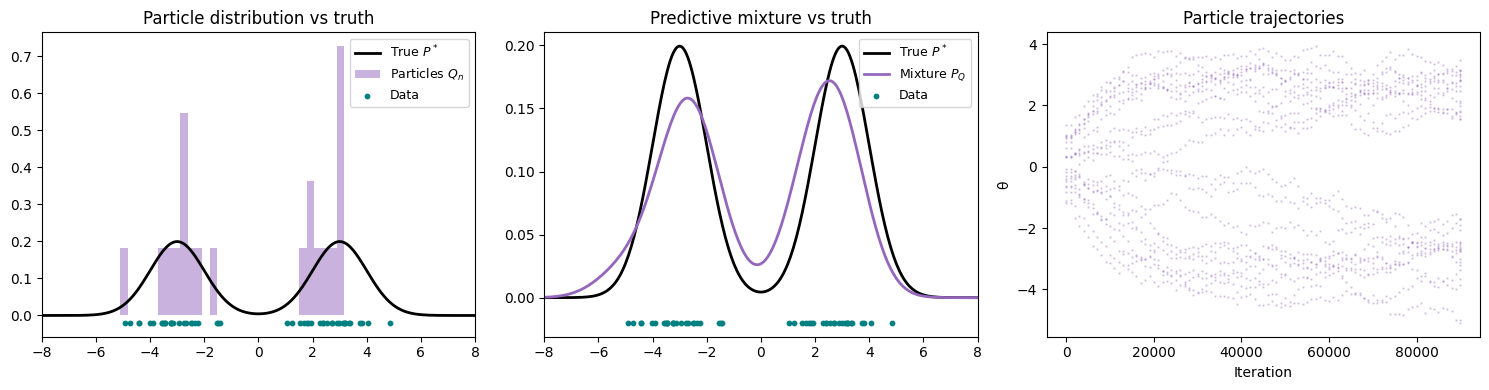

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Particle histogram vs true data distribution
ax = axes[0]
x_grid = np.linspace(-8, 8, 300)
true_density = 0.5 * stats.norm.pdf(x_grid, -3, 1) + 0.5 * stats.norm.pdf(x_grid, 3, 1)
ax.plot(x_grid, true_density, 'k-', lw=2, label='True $P^*$')
ax.hist(particles, bins=30, density=True, alpha=0.5, color='tab:purple', label='Particles $Q_n$')
ax.scatter(data, np.zeros(n) - 0.02, c='teal', s=10, zorder=5, label='Data')
ax.set_title('Particle distribution vs truth')
ax.legend(fontsize=9)
ax.set_xlim(-8, 8)

# 2. Mixture predictive vs data
ax = axes[1]
mixture_density = np.zeros_like(x_grid)
for th in particles:
    mixture_density += stats.norm.pdf(x_grid, th, sigma)
mixture_density /= NE
ax.plot(x_grid, true_density, 'k-', lw=2, label='True $P^*$')
ax.plot(x_grid, mixture_density, '-', color='tab:purple', lw=2, label='Mixture $P_Q$')
ax.scatter(data, np.zeros(n) - 0.02, c='teal', s=10, zorder=5, label='Data')
ax.set_title('Predictive mixture vs truth')
ax.legend(fontsize=9)
ax.set_xlim(-8, 8)

# 3. Particle evolution over time
ax = axes[2]
for i, snap in enumerate(history):
    t_val = i * 1000 if i < len(history) - 1 else K
    ax.scatter(np.full_like(snap, t_val), snap, s=0.5, c='tab:purple', alpha=0.3)
ax.set_xlabel('Iteration')
ax.set_ylabel('θ')
ax.set_title('Particle trajectories')

plt.tight_layout()
plt.show()

Running bandwidth sweep...


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

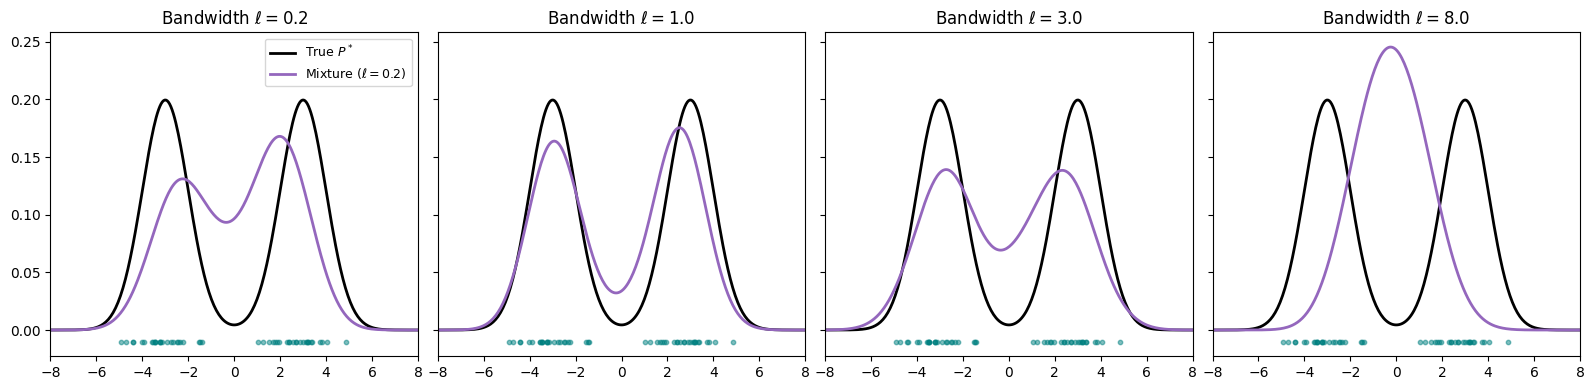

In [60]:
# --- Data Setup ---
np.random.seed(42)
n = 50
data = np.concatenate([
    np.random.normal(-3, 1, n // 2),
    np.random.normal(3, 1, n // 2)
])

# --- Core Simulation Function ---
def run_particle_descent(ell, NE=300, K=15000, eta=1e-3, lambda_n=0.01, sigma=1.0):
    """Runs the simulation for a given bandwidth 'ell' and returns the final particles."""
    # Precompute constants for this specific ell
    s1 = np.sqrt(ell**2 + sigma**2)
    s2 = np.sqrt(ell**2 + 2 * sigma**2)
    c1 = ell / s1
    c2 = ell / s2

    particles = np.random.randn(NE) # Init from prior
    
    for _ in tqdm(range(K)):
        # 1. Prior Gradient
        gv = lambda_n * particles
        
        # 2. Cross-term Gradient (Data interaction)
        diff_cross = particles[None, :] - data[:, None]  
        sq_cross = diff_cross ** 2
        vals_cross = c1 * np.exp(-sq_cross / (2 * s1**2))
        g_cross = -np.mean(vals_cross * diff_cross / s1**2, axis=0)
        
        # 3. Model-Model Gradient (Particle repulsion)
        diff_mm = particles[:, None] - particles[None, :] 
        g_mm = -c2 * np.exp(-diff_mm**2 / (2 * s2**2)) * diff_mm / s2**2
        np.fill_diagonal(g_mm, 0)
        interaction = g_mm.sum(axis=1) / (NE - 1)
        
        # 4. Update
        drift = gv - g_cross + interaction
        noise = np.random.randn(NE) * np.sqrt(2 * lambda_n * eta)
        particles = particles - eta * drift + noise
        
    return particles

# --- Run the Sweep ---
ell_values = [0.2, 1.0, 3.0, 8.0]
results = {}

print("Running bandwidth sweep...")
for ell in tqdm(ell_values):
    results[ell] = run_particle_descent(ell=ell, NE=150, K=100000)

# --- Visualise the Converged Distributions ---
fig, axes = plt.subplots(1, len(ell_values), figsize=(16, 4), sharey=True)
x_grid = np.linspace(-8, 8, 300)
true_density = 0.5 * stats.norm.pdf(x_grid, -3, 1) + 0.5 * stats.norm.pdf(x_grid, 3, 1)

for ax, ell in zip(axes, ell_values):
    final_particles = results[ell]
    
    # Calculate predictive mixture
    mixture_density = np.zeros_like(x_grid)
    for th in final_particles:
        mixture_density += stats.norm.pdf(x_grid, th, scale=1.0)
    mixture_density /= len(final_particles)
    
    ax.plot(x_grid, true_density, 'k-', lw=2, label='True $P^*$')
    ax.plot(x_grid, mixture_density, '-', color='tab:purple', lw=2, label=f'Mixture ($\\ell={ell}$)')
    ax.scatter(data, np.zeros(n) - 0.01, c='teal', s=10, alpha=0.5)
    ax.set_title(f'Bandwidth $\\ell = {ell}$')
    ax.set_xlim(-8, 8)
    if ell == ell_values[0]:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

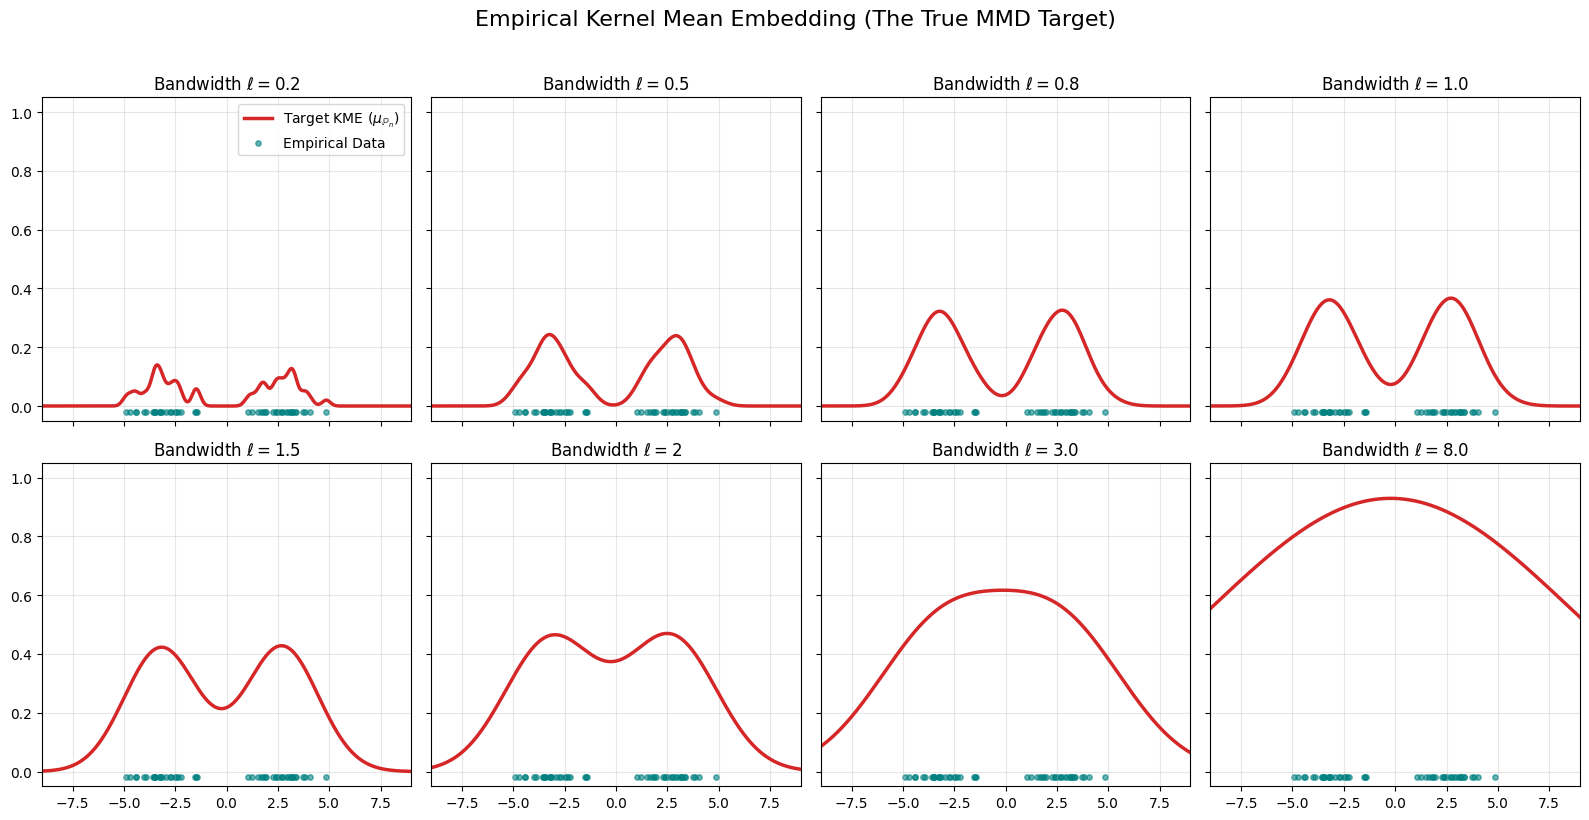

In [47]:
# --- Data Setup ---
np.random.seed(42)
n = 50
data = np.concatenate([
    np.random.normal(-3, 1, n // 2),
    np.random.normal(3, 1, n // 2)
])

# --- Kernel Mean Embedding Function ---
def empirical_kme(x_grid, data, ell):
    """
    Computes the empirical Kernel Mean Embedding of the data
    evaluated over a grid of points.
    Kernel: k(x, y) = exp(-|x - y|^2 / (2 * ell^2))
    """
    # Broadcast to calculate pairwise squared distances
    # x_grid shape: (M, 1), data shape: (1, n)
    sq_dist = (x_grid[:, None] - data[None, :])**2
    
    # Apply the Gaussian kernel
    kernel_matrix = np.exp(-sq_dist / (2 * ell**2))
    
    # The KME is the mean of the kernel evaluations across all data points
    return np.mean(kernel_matrix, axis=1)

# --- Visualisation ---
x_grid = np.linspace(-10, 10, 400)
ell_values = [0.2, 0.5, 0.8, 1.0, 1.5, 2, 3.0, 8.0]

fig, axes = plt.subplots(2, len(ell_values)//2, figsize=(4*len(ell_values)//2, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, ell in zip(axes, ell_values):
    # Calculate the target embedding
    kme_target = empirical_kme(x_grid, data, ell)
    
    # Plot the KME
    ax.plot(x_grid, kme_target, color='tab:red', lw=2.5, label=f'Target KME ($\\mu_{{\\mathbb{{P}}_n}}$)')
    
    # Plot the raw data points on the x-axis for reference
    ax.scatter(data, np.zeros(n) - 0.02, c='teal', s=15, alpha=0.6, label='Empirical Data')
    
    ax.set_title(f'Bandwidth $\\ell = {ell}$')
    ax.set_xlim(-9, 9)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    
    if ell == ell_values[0]:
        ax.legend(loc='upper right')

plt.suptitle("Empirical Kernel Mean Embedding (The True MMD Target)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

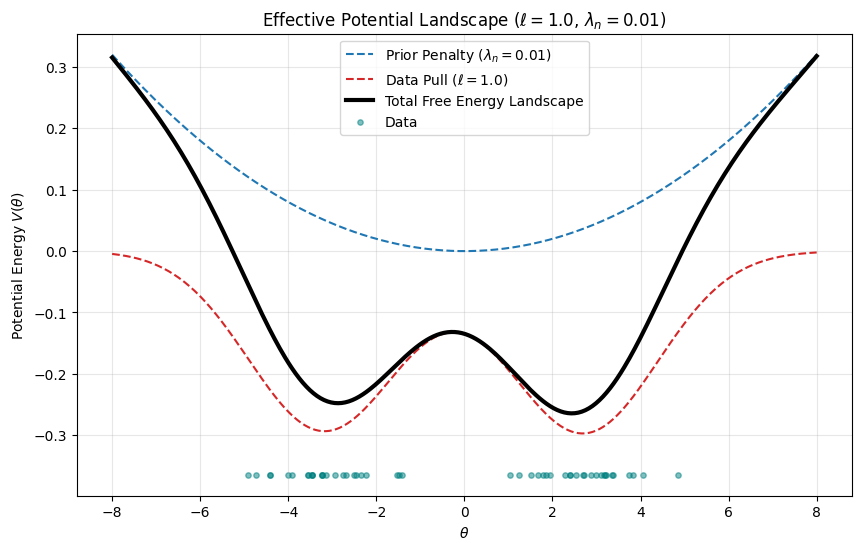

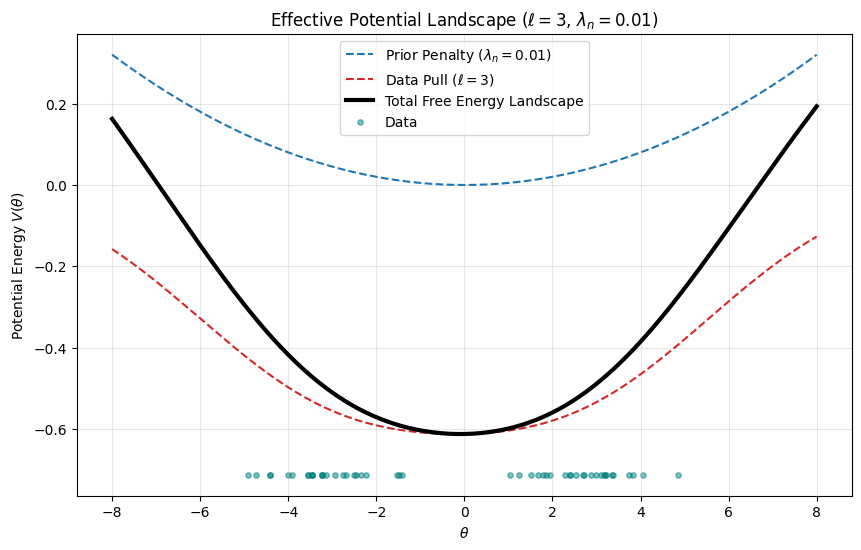

In [68]:
def plot_potential_landscape(ell, lambda_n, sigma=1.0):
    s1 = np.sqrt(ell**2 + sigma**2)
    c1 = ell / s1
    
    theta_grid = np.linspace(-8, 8, 400)
    
    # 1. Prior Potential (Quadratic Bowl)
    v_prior = 0.5 * lambda_n * theta_grid**2
    
    # 2. Data Potential (Inverted KME-style cross term)
    sq_diff = (theta_grid[:, None] - data[None, :])**2
    v_data = -c1 * np.mean(np.exp(-sq_diff / (2 * s1**2)), axis=1)
    
    # 3. Total Potential
    v_total = v_prior + v_data
    
    plt.figure(figsize=(10, 6))
    plt.plot(theta_grid, v_prior, '--', color='tab:blue', label=f'Prior Penalty ($\\lambda_n={lambda_n}$)')
    plt.plot(theta_grid, v_data, '--', color='tab:red', label=f'Data Pull ($\\ell={ell}$)')
    plt.plot(theta_grid, v_total, '-', color='k', lw=3, label='Total Free Energy Landscape')
    
    plt.scatter(data, np.full(n, min(v_total) - 0.1), c='teal', s=15, alpha=0.5, label='Data')
    plt.title(f'Effective Potential Landscape ($\\ell={ell}$, $\\lambda_n={lambda_n}$)')
    plt.xlabel(r'$\theta$')
    plt.ylabel('Potential Energy $V(\\theta)$')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Try running this with a high lambda vs a low lambda!
plot_potential_landscape(ell=1.0, lambda_n=0.01)
plot_potential_landscape(ell=3, lambda_n=0.01)

### Trying same as before + adam optimiser
> Something is wrong here - instable in some areas for some reason ..

In [ ]:
particles_adam = np.random.randn(NE)  # init from prior N(0,1)

# Adam state
m = np.zeros(NE)  # first moment
v = np.zeros(NE)  # second moment
beta1, beta2, eps_adam = 0.5, 0.9, 1e-8

history_adam = [particles_adam.copy()]

for t in tqdm(range(K//3)):
    gv = grad_v(particles_adam)
    g_cross = grad_cross_term(particles_adam)
    g_mm = grad_model_model(particles_adam)

    np.fill_diagonal(g_mm, 0)
    interaction = g_mm.sum(axis=1) / (NE - 1)

    drift = gv - g_cross + interaction

    # Adam update
    m = beta1 * m + (1 - beta1) * drift
    v = beta2 * v + (1 - beta2) * drift**2
    m_hat = m / (1 - beta1**(t + 1))
    v_hat = v / (1 - beta2**(t + 1))

    noise = np.random.randn(NE) * np.sqrt(2 * lambda_n * eta)

    particles_adam = particles_adam - eta * m_hat / (np.sqrt(v_hat) + eps_adam) + noise*10

    if t % 1000 == 0:
        # print(eta * m_hat / (np.sqrt(v_hat) + eps_adam))
        history_adam.append(particles_adam.copy())

history_adam.append(particles_adam.copy())

  0%|          | 0/30000 [00:00<?, ?it/s]

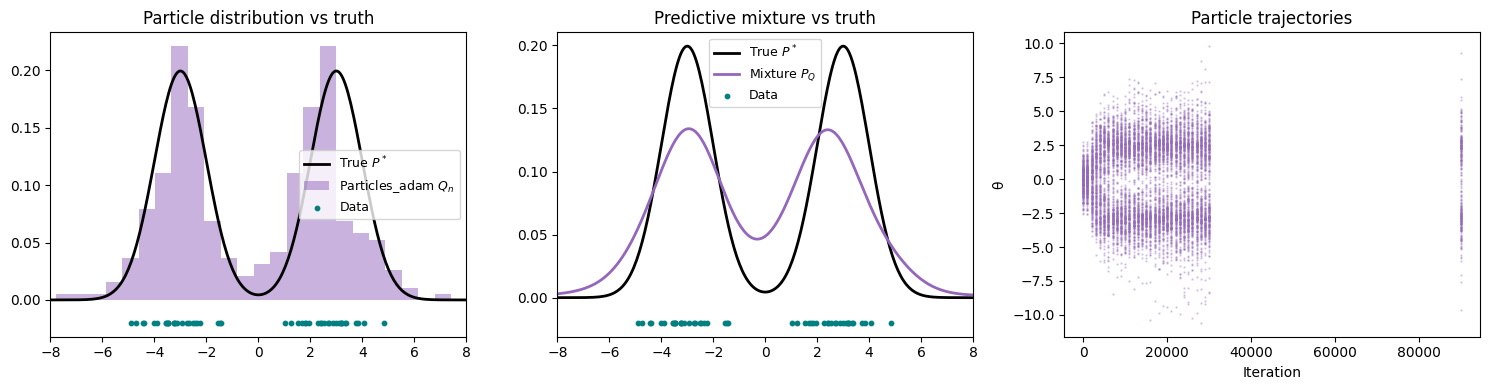

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Particle histogram vs true data distribution
ax = axes[0]
x_grid = np.linspace(-8, 8, 300)
true_density = 0.5 * stats.norm.pdf(x_grid, -3, 1) + 0.5 * stats.norm.pdf(x_grid, 3, 1)
ax.plot(x_grid, true_density, 'k-', lw=2, label='True $P^*$')
ax.hist(particles_adam, bins=30, density=True, alpha=0.5, color='tab:purple', label='Particles_adam $Q_n$')
ax.scatter(data, np.zeros(n) - 0.02, c='teal', s=10, zorder=5, label='Data')
ax.set_title('Particle distribution vs truth')
ax.legend(fontsize=9)
ax.set_xlim(-8, 8)

# 2. Mixture predictive vs data
ax = axes[1]
mixture_density = np.zeros_like(x_grid)
for th in particles_adam:
    mixture_density += stats.norm.pdf(x_grid, th, sigma)
mixture_density /= NE
ax.plot(x_grid, true_density, 'k-', lw=2, label='True $P^*$')
ax.plot(x_grid, mixture_density, '-', color='tab:purple', lw=2, label='Mixture $P_Q$')
ax.scatter(data, np.zeros(n) - 0.02, c='teal', s=10, zorder=5, label='Data')
ax.set_title('Predictive mixture vs truth')
ax.legend(fontsize=9)
ax.set_xlim(-8, 8)

# 3. Particle evolution over time
ax = axes[2]
for i, snap in enumerate(history_adam):
    t_val = i * 1000 if i < len(history_adam) - 1 else K
    ax.scatter(np.full_like(snap, t_val), snap, s=0.5, c='tab:purple', alpha=0.3)
ax.set_xlabel('Iteration')
ax.set_ylabel('θ')
ax.set_title('Particle trajectories')

plt.tight_layout()
plt.show()

Kernel mean embedding as  
$$\mu_k(P) := \int k(\cdot, y) d P(y) \in \mathcal{H}(k)$$
Then the divergence of a candidate $P \in \mathcal{P}(\mathcal{Y})$ from the data-generating distribution $P_\star$ is given by the MMD  
$$MMD(P_\star, P) = \| \mu_k(P_\star) - \mu_k(P)\|_{\mathcal{H}(k)}$$
 - proper metrix if $k$ is the characteristic kernel
 - Statistical divergence by "proper scoring rule [Dawid, 1986]

<br>

Mixture model; $$P_Q = \int P_\theta dQ(\theta) \in \mathcal{P}(\mathcal{Y})$$  
the mean embedding for the $P_Q$ is given as 

$$
\begin{aligned}
\mu_k(P_Q) &= \int k(\cdot, y) d P_Q(y) \\ &= \int k(\cdot, y)\int P_\theta dQ(\theta) \\ &= \int \int k(\cdot, y) P_\theta dQ(\theta) \\ &= \int \mu_k (P_{\theta}) dQ(\theta)
\end{aligned}
$$

which means that 
$$MMD^2(P_\star, P) = \left\| \int \{ \mu_k(P_\star) - \mu_k(P_\theta) \}\right\|^2_{\mathcal{H}(k)} = \int\int\kappa_{P_{\star}}(\theta, \mathscr{v}) dQ(\theta)dQ(\mathbb{v})$$
 - last step is from explanding the norm using the inner product then exchanging inner product and intergral
$$\begin{aligned}
\left\| \int \{ \dots \} dQ(\theta) \right\|^2 &= \langle \int (\dots) dQ(\theta), \int (\dots) dQ(\mathscr{v}) \rangle \\
&= \int \int \langle \mu_k(P_\star) - \mu_k(P_\theta), \mu_k(P_\star) - \mu_k(P_{\mathscr{v}}) \rangle_{\mathcal{H}(k)} dQ(\theta) dQ(\mathscr{v})
\end{aligned}
$$


where


$$
\begin{aligned}
 \kappa_{P_{\star}}(\theta, \mathscr{v}) &= \langle \mu_k(P_\star) - \mu_k(P_\theta), \mu_k(P_\star) - \mu_k(P_{\mathscr{v}}) \rangle_{\mathcal{H}(k)} \\
  &= \langle \mu_k(P^\star), \mu_k(P^\star) \rangle - \langle \mu_k(P^\star), \mu_k(P_\vartheta) \rangle - \langle \mu_k(P_\theta), \mu_k(P^\star) \rangle + \langle \mu_k(P_\theta), \mu_k(P_\vartheta) \rangle
\end{aligned}
$$

Gives us 4 terms  
- data vs data = constant 
- data vs model 1
- data vs model 2
- model 1 vs model 2 where 


$$\kappa_{P^\star}(\theta, \vartheta) \stackrel{+C}{=} \iint k(y,y') \, dP_\theta(y) \, dP_\vartheta(y') - \iint k(y,y') \, dP_\theta(y) \, dP^\star(y') - \iint k(y,y') \, dP^\star(y) \, dP_\vartheta(y')$$
----

In practice we dont have the true data generating function $P_\star$ so we replace it with the empirical distribution $P_n = \frac{1}{n}\sum_i\delta_{y_i}$. Bellow the same as above but with the replaced $P_n$
$$\kappa_{P_n}(\theta, \vartheta) = \iint k(y,y') \, dP_\theta(y) \, dP_\vartheta(y') - \frac{1}{n}\sum_{i=1}^n \int k(y_i, y) \, dP_\theta(y) - \frac{1}{n}\sum_{i=1}^n \int k(y_i, y) \, dP_\vartheta(y)$$

$$
\begin{align}
\mathcal{F}_n(Q) &= \underbrace{ \underbrace{\frac{1}{2} \iint \kappa_{P_n}(\theta, \vartheta) \, dQ(\theta) \, dQ(\vartheta)}_{\text{interaction energy}} + \underbrace{\int v(\theta) \, dQ(\theta)}_{\text{single-particle (prior)}} }_{\mathcal{E}_n(Q) \text{ (free energy)}} + \underbrace{\lambda_n \int \log q(\theta) \, dQ(\theta)}_{\text{negative entropy}}  \\

 &= \frac{1}{2}\iint \kappa_{P_n}(\theta, \vartheta)\, dQ(\theta)\, dQ(\vartheta) + \lambda_n\, \text{KL}(Q \| Q_0)

\end{align}$$

Taking the gradint of eveything for the particle update

$$
\begin{aligned}
    &\text{Functional Gradient:} \quad &\nabla_W \mathcal{E}_n(Q_t)(\theta_t) &= \nabla v(\theta_t) + \int \nabla_1 \kappa_{P_n}(\theta_t, \vartheta) \, dQ_t(\vartheta) \\[12pt]
    &\text{Particle Update (SDE):} \quad &d\theta_t &= -\nabla_W \mathcal{E}_n(Q_t)(\theta_t) \, dt + \sqrt{2\lambda_n} \, dW_t
\end{aligned}$$
----

approximate $Q_t$ with $N$ particles $\theta^1_t, \dots, \theta^N_t$. The empirical distribution is:


$$Q_t \approx \hat{Q}^t_N = \frac{1}{N}\sum_{j=1}^N \delta_{\theta^j_t}$$
Now plug this into the integral:


$$\int \nabla_1 \kappa_{P_n}(\theta^i_t, \vartheta) \, dQ_t(\vartheta) \approx \int \nabla_1 \kappa_{P_n}(\theta^i_t, \vartheta) \, \frac{1}{N}\sum_{j=1}^N \delta_{\theta^j_t}(\vartheta)$$
The deltas collapse the integral into a sum. But you exclude $j = i$ (a particle shouldn't interact with itself), and compensate by using $N-1$:


$$= \frac{1}{N-1}\sum_{j \neq i} \nabla_1 \kappa_{P_n}(\theta^i_t, \theta^j_t)$$
Substitute this back into the SDE, and give each particle its own independent Wiener process $W^i_t$:


$$d\theta^i_t = -\left(\nabla v(\theta^i_t) + \frac{1}{N-1}\sum_{j \neq i} \nabla_1 \kappa_{P_n}(\theta^i_t, \theta^j_t)\right) dt + \sqrt{2\lambda_n} \, dW^i_t$$


In [ ]:
def rbf_kernel(x, y, h=1.0):
    diff = x[:, None, :] - y[None, :, :]
    dist_sq = np.sum(diff**2, axis=-1)
    return np.exp(-dist_sq / (2 * h**2))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def w1(x): return sigmoid(-5 * x)  # Expert 1 gate
def w2(x): return sigmoid(5 * x)   # Expert 2 gate

# --- 3. The Experts (Particles) ---
n_e = 500  # Particles per expert

# Expert 1 (left mode)
x_e1 = np.random.randn(n_e, 1) - 0.0

# Expert 2 (right mode)
x_e2 = np.random.randn(n_e, 1) + 0.0

# --- 4. Evaluate MMD Self-Interaction Components ---

# Intra-Expert 1
K_11 = rbf_kernel(x_e1, x_e1)
weight_matrix_11 = w1(x_e1) @ w1(x_e1).T
intra_1 = np.mean(weight_matrix_11 * K_11)

# Intra-Expert 2
K_22 = rbf_kernel(x_e2, x_e2)
weight_matrix_22 = w2(x_e2) @ w2(x_e2).T
intra_2 = np.mean(weight_matrix_22 * K_22)

# Inter-Expert (Cross-term)
K_12 = rbf_kernel(x_e1, x_e2)
weight_matrix_12 = w1(x_e1) @ w2(x_e2).T
cross_12 = np.mean(weight_matrix_12 * K_12)

# Total
total_T_self = intra_1 + intra_2 + (2 * cross_12)

print(f"--- MMD T_self Breakdown ({n_e} particles per expert) ---")
print(f"Intra-Expert 1 Term  : {intra_1:.6f}")
print(f"Intra-Expert 2 Term  : {intra_2:.6f}")
print(f"Inter-Expert (Cross) : {cross_12:.8f}")
print("-" * 50)
print(f"Total T_self         : {total_T_self:.6f}")
print(f"% Compute Wasted on Cross-terms: {(2 * cross_12 / total_T_self) * 100:.6f}%")

--- MMD T_self Breakdown (500 particles per expert) ---
Intra-Expert 1 Term  : 0.188746
Intra-Expert 2 Term  : 0.196802
Inter-Expert (Cross) : 0.10232574
--------------------------------------------------
Total T_self         : 0.590199
% Compute Wasted on Cross-terms: 34.674977%


#### Testing full MMD with MoE

### Questions
1. I dont really understand how the negative entropy term becomes standard brownian motion
 1.1. How does this motion actually effect the distribution, e.g. does a fatter tailed normal brownian => differnt target distribtion? or is the direct brownian result nessesitate normal
2. rbf kernel thigns about the sigma computed at every step vs..

>"Kernel lengthscale, σκ, is chosen according to the median heuristic (Garreau et al., 2017)
based on samples from the prior P"

## N dim kernel

0.36787944117144233


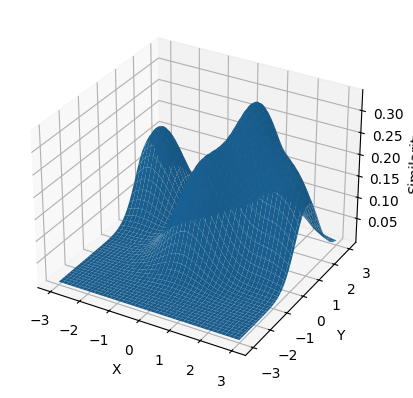

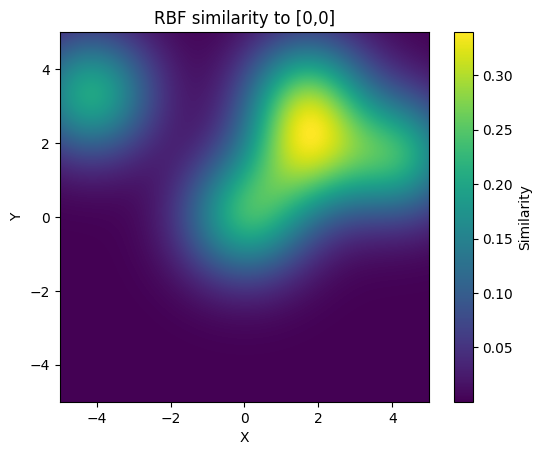

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rbf_kernel(x1, x2, h=1):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    return np.exp(-np.sum((x1 - x2)**2, axis=-1) / h)

# example: similarity between two points
print(rbf_kernel([0, 0], [1, 0]))  # scalar

# grid
X, Y = np.meshgrid(np.linspace(-3, 3, 401), np.linspace(-3, 3, 401))
grid = np.stack([X, Y], axis=-1)   # shape (201, 201, 2)

# compare [0,0] to entire grid
points = [[0,0], [1,2], [1,1], [2.5,1], [-2.5,2]]
Z = 0
for point in points:
    Z += 1/len(points) * rbf_kernel(point, grid, 1)

# plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Similarity')

plt.show()
plt.imshow(Z, extent=[-5, 5, -5, 5], origin='lower')
plt.colorbar(label='Similarity')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('RBF similarity to [0,0]')
plt.show()

In [85]:
from scipy.ndimage import gaussian_filter1d


# --- Grid Setup ---
GRID_POINTS = 500
theta_grid = np.linspace(-10, 10, GRID_POINTS)
d_theta = theta_grid[1] - theta_grid[0]

def solve_mean_field_stationary(ell, lambda_n=0.01, sigma=1.0, max_iter=20000, tol=1e-7, alpha=0.1):
    """
    Solves the non-linear integro-differential stationary equation using Fixed-Point Iteration.
    alpha is a damping factor (0 to 1) to prevent oscillations during the update.
    """
    s1 = np.sqrt(ell**2 + sigma**2)
    s2 = np.sqrt(ell**2 + 2 * sigma**2)
    c1 = ell / s1
    c2 = ell / s2
    
    # 1. Precompute Static Potential V(theta)
    # Prior potential
    v_prior = 0.5 * lambda_n * theta_grid**2
    
    # Data cross-term potential
    sq_diff_data = (theta_grid[:, None] - data[None, :])**2
    v_data = -c1 * np.mean(np.exp(-sq_diff_data / (2 * s1**2)), axis=1)
    
    V_total = v_prior + v_data
    
    # 2. Precompute Kernel Matrix for the integral
    diff_grid = theta_grid[:, None] - theta_grid[None, :]
    K_matrix = c2 * np.exp(-diff_grid**2 / (2 * s2**2))
    
    # Diffusion constant (temperature)
    D = lambda_n 
    
    # 3. Initialize density guess (Uniform or Gaussian)
    q_current = stats.norm.pdf(theta_grid, 0, 2)
    q_current /= np.sum(q_current) * d_theta
    
    # 4. Fixed-Point Iteration Loop
    for i in range(max_iter):
        # Calculate convolution: integral of k(theta, theta') * q(theta') dtheta'
        repulsion = (K_matrix @ q_current) * d_theta
        
        # Calculate new target density
        exponent = -(V_total + repulsion) / D
        
        # Shift exponent for numerical stability before exp()
        exponent -= np.max(exponent) 
        q_new = np.exp(exponent)
        
        # Normalize
        q_new /= np.sum(q_new) * d_theta
        
        # Check convergence (Mean Absolute Error)
        diff = np.mean(np.abs(q_new - q_current))
        if diff < tol:
            # print(f"Converged for ell={ell} at iteration {i}")
            return q_new
            
        # Damped update (critical for stability in mean-field equations)
        q_current = alpha * q_new + (1 - alpha) * q_current
        
    print(f"Warning: ell={ell} did not perfectly converge. Diff: {diff}")
    return q_current

In [95]:
# --- Run the Analysis ---
ell_values = np.linspace(0.2, 5.0, 25)
stationary_dists = {}

print("Solving mean-field equations...")
for ell in ell_values:
    stationary_dists[ell] = solve_mean_field_stationary(ell)

Solving mean-field equations...


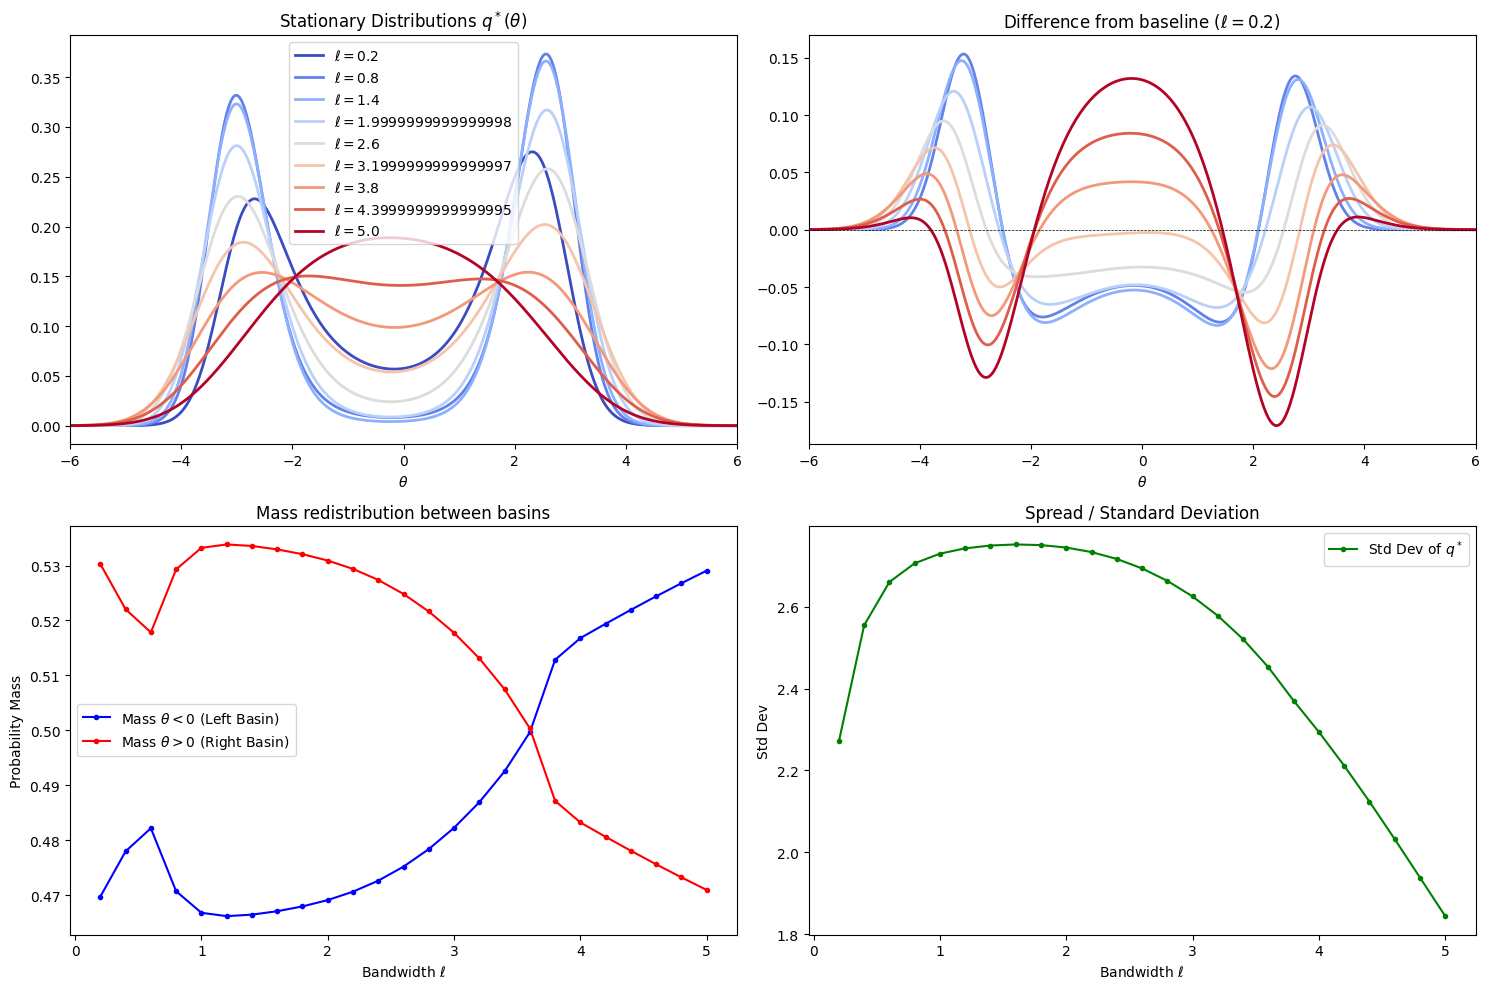

In [100]:

# --- Generate Plots (matching your uploaded style) ---
fig = plt.figure(figsize=(15, 10))

# 1. Stationary Distributions (for a subset of bandwidths)
ax1 = plt.subplot(2, 2, 1)
plot_ells = ell_values[::3]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(plot_ells)))

for ell, color in zip(plot_ells, colors):
    ax1.plot(theta_grid, stationary_dists[ell], label=f'$\\ell = {ell}$', color=color, lw=2)
ax1.set_title('Stationary Distributions $q^*(\\theta)$')
ax1.set_xlabel('$\\theta$')
ax1.legend()
ax1.set_xlim(-6, 6)

# 2. Difference from lowest bandwidth (baseline)
ax2 = plt.subplot(2, 2, 2)
baseline = stationary_dists[plot_ells[0]]
for ell, color in zip(plot_ells[1:], colors[1:]):
    diff = stationary_dists[ell] - baseline
    ax2.plot(theta_grid, diff, label=f'$\\ell = {ell}$', color=color, lw=2)
ax2.axhline(0, color='k', linestyle='--', lw=0.5)
ax2.set_title(f'Difference from baseline ($\\ell={plot_ells[0]}$)')
ax2.set_xlabel('$\\theta$')
ax2.set_xlim(-6, 6)

# 3. Mass Redistribution (Left Basin vs Right Basin)
ax3 = plt.subplot(2, 2, 3)
mass_left = []
mass_right = []
for ell in ell_values:
    q = stationary_dists[ell]
    mass_left.append(np.sum(q[theta_grid < 0]) * d_theta)
    mass_right.append(np.sum(q[theta_grid >= 0]) * d_theta)

ax3.plot(ell_values, mass_left, 'b.-', label='Mass $\\theta < 0$ (Left Basin)')
ax3.plot(ell_values, mass_right, 'r.-', label='Mass $\\theta > 0$ (Right Basin)')
ax3.set_title('Mass redistribution between basins')
ax3.set_xlabel('Bandwidth $\\ell$')
ax3.set_ylabel('Probability Mass')
ax3.legend()

# 4. Spread and Concentration (Standard Deviation)
ax4 = plt.subplot(2, 2, 4)
std_devs = []
for ell in ell_values:
    q = stationary_dists[ell]
    mean_val = np.sum(theta_grid * q) * d_theta
    var_val = np.sum((theta_grid - mean_val)**2 * q) * d_theta
    std_devs.append(np.sqrt(var_val))

ax4.plot(ell_values, std_devs, 'g.-', label='Std Dev of $q^*$')
ax4.set_title('Spread / Standard Deviation')
ax4.set_xlabel('Bandwidth $\\ell$')
ax4.set_ylabel('Std Dev')
ax4.legend()

plt.tight_layout()
plt.show()

Solving mean-field equations for fixed ell=1.0...


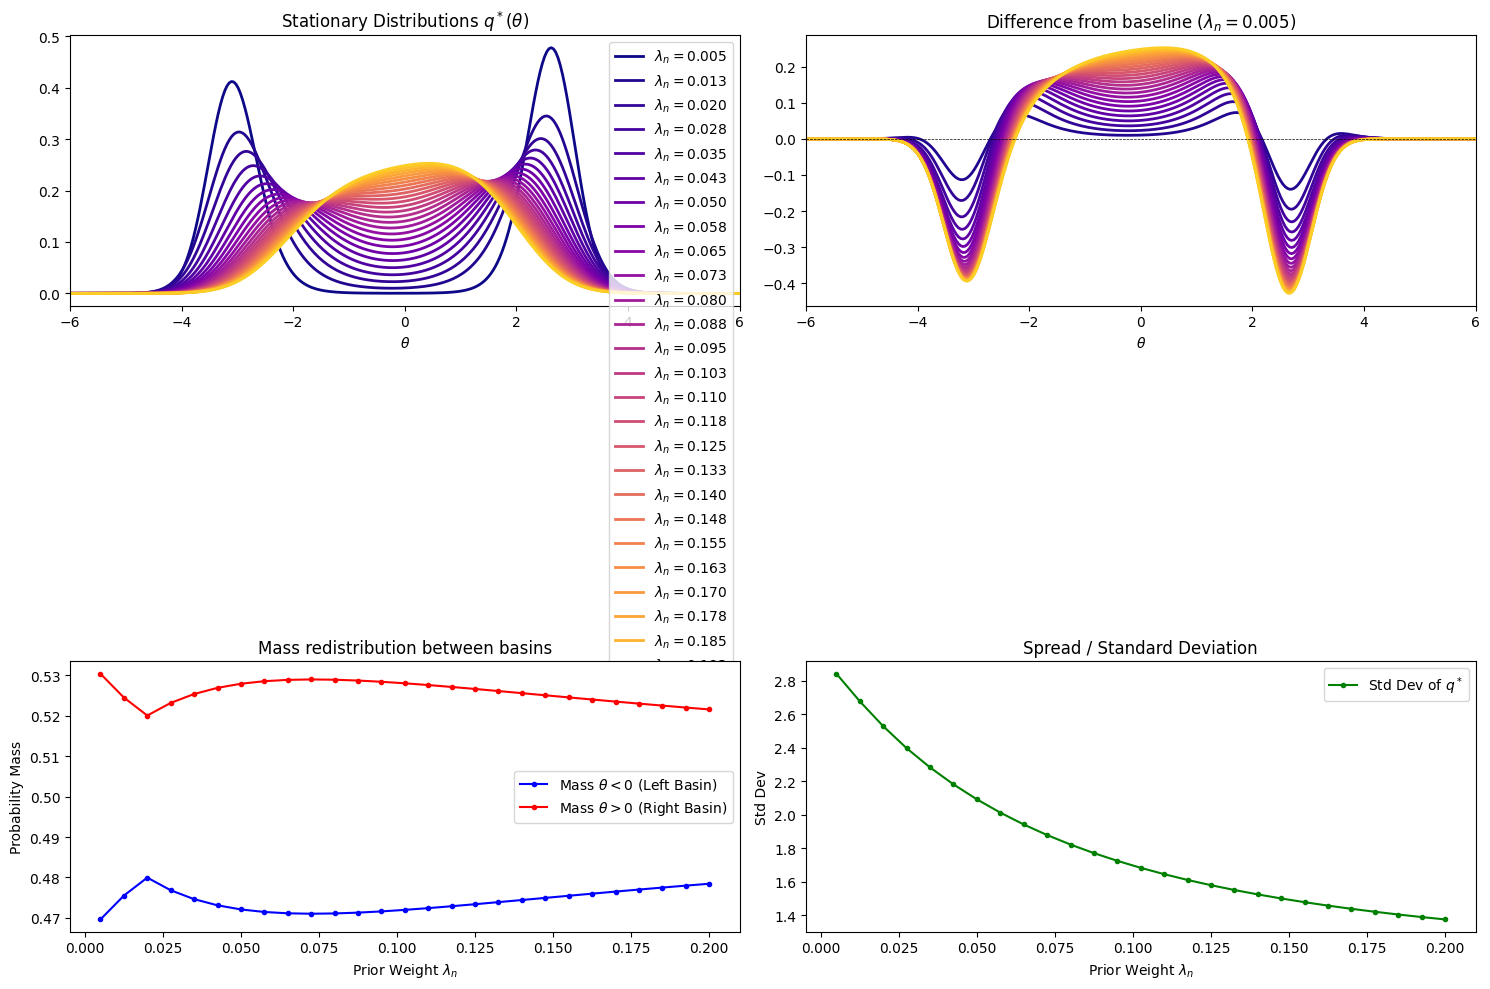

In [104]:
# --- Run the Analysis for Lambda ---
# Lock bandwidth to a value that allows bimodality
fixed_ell = 1.0 

# Sweep lambda from very weak prior (0.005) to strong prior (0.2)
lambda_values = np.linspace(0.005, 0.2, 27)
stationary_dists = {}

print(f"Solving mean-field equations for fixed ell={fixed_ell}...")
for lam in lambda_values:
    # Notice we pass the sweeping 'lam' into the lambda_n argument
    stationary_dists[lam] = solve_mean_field_stationary(ell=fixed_ell, lambda_n=lam)

# --- Generate Plots (matching your uploaded style) ---
fig = plt.figure(figsize=(15, 10))

# Select a few specific lambda values to draw as curves
plot_lambdas = lambda_values
colors = plt.cm.plasma(np.linspace(0, 0.9, len(plot_lambdas)))

# 1. Stationary Distributions
ax1 = plt.subplot(2, 2, 1)
for lam, color in zip(plot_lambdas, colors):
    ax1.plot(theta_grid, stationary_dists[lam], label=f'$\\lambda_n = {lam:.3f}$', color=color, lw=2)
ax1.set_title('Stationary Distributions $q^*(\\theta)$')
ax1.set_xlabel('$\\theta$')
ax1.legend()
ax1.set_xlim(-6, 6)

# 2. Difference from lowest lambda (baseline)
ax2 = plt.subplot(2, 2, 2)
baseline = stationary_dists[plot_lambdas[0]]
for lam, color in zip(plot_lambdas[1:], colors[1:]):
    diff = stationary_dists[lam] - baseline
    ax2.plot(theta_grid, diff, label=f'$\\lambda_n = {lam:.3f}$', color=color, lw=2)
ax2.axhline(0, color='k', linestyle='--', lw=0.5)
ax2.set_title(f'Difference from baseline ($\\lambda_n={plot_lambdas[0]:.3f}$)')
ax2.set_xlabel('$\\theta$')
ax2.set_xlim(-6, 6)

# 3. Mass Redistribution (Left Basin vs Right Basin)
ax3 = plt.subplot(2, 2, 3)
mass_left = []
mass_right = []
for lam in lambda_values:
    q = stationary_dists[lam]
    mass_left.append(np.sum(q[theta_grid < 0]) * d_theta)
    mass_right.append(np.sum(q[theta_grid >= 0]) * d_theta)

ax3.plot(lambda_values, mass_left, 'b.-', label='Mass $\\theta < 0$ (Left Basin)')
ax3.plot(lambda_values, mass_right, 'r.-', label='Mass $\\theta > 0$ (Right Basin)')
ax3.set_title('Mass redistribution between basins')
ax3.set_xlabel('Prior Weight $\\lambda_n$')
ax3.set_ylabel('Probability Mass')
ax3.legend()

# 4. Spread and Concentration (Standard Deviation)
ax4 = plt.subplot(2, 2, 4)
std_devs = []
for lam in lambda_values:
    q = stationary_dists[lam]
    mean_val = np.sum(theta_grid * q) * d_theta
    var_val = np.sum((theta_grid - mean_val)**2 * q) * d_theta
    std_devs.append(np.sqrt(var_val))

ax4.plot(lambda_values, std_devs, 'g.-', label='Std Dev of $q^*$')
ax4.set_title('Spread / Standard Deviation')
ax4.set_xlabel('Prior Weight $\\lambda_n$')
ax4.set_ylabel('Std Dev')
ax4.legend()

plt.tight_layout()
plt.show()